In [1]:
# Init pack

import numpy as np
from scipy.integrate import solve_ivp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sys
import torch
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast
from torch.nn.parallel import DataParallel
import seaborn as sns

plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

data = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')

data = data[:,1,:]

# for i in range(25):
#     plt.plot(data[:10_000,50+i], label=f'Variable {i}')
#     plt.show()
#     sns.histplot(data[:10_000,50+i], bins=50, kde=True)
#     plt.title(f'Variable {i} Distribution')
#     plt.show()

# Normalization
mean = np.mean(data, axis=0, keepdims=True)
std = np.std(data, axis=0, keepdims=True)
data = (data - mean) / std

# Pre-processing

index = 63
num_variables = 50

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim, num_neurons):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(75, num_neurons)  # Input layer (75) -> Hidden layer (1024)
        self.fc2 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc3 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc4 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc5 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc6 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc_mu = nn.Linear(num_neurons, latent_dim)  # Hidden layer (1024) -> Latent space (32)
        self.fc_logvar = nn.Linear(num_neurons, latent_dim)  # Hidden layer (1024) -> Log variance (32)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Activation function for hidden layer
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + condition_dim, num_neurons)  # Input layer (32 + 50) -> Hidden layer (1024)
        self.fc2 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc3 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc4 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc5 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc6 = nn.Linear(num_neurons, num_neurons)  # Hidden layer (1024) -> Hidden layer (1024)
        self.fc_output = nn.Linear(num_neurons, output_dim)  # Hidden layer (1024) -> Output layer (75)

    def forward(self, z, condition):
        z = torch.cat((z, condition), dim=1)  # Concatenate latent vector and condition
        z = torch.relu(self.fc1(z))  # Activation function for hidden layer
        z = torch.relu(self.fc2(z)) + z
        z = torch.relu(self.fc3(z)) + z
        z = torch.relu(self.fc4(z)) + z
        z = torch.relu(self.fc5(z)) + z
        z = torch.relu(self.fc6(z)) + z
        output = self.fc_output(z)
        return output

# Define the VAE model
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(ConditionalVAE, self).__init__()
        self.encoder = Encoder(latent_dim, num_neurons)
        self.decoder = Decoder(latent_dim, output_dim, condition_dim, num_neurons)

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z, condition):
        return self.decoder(z, condition)

    def forward(self, x, condition):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z, condition)
        return output, mu, logvar

In [3]:
# PREP
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import os, random
import itertools

save_dir        = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths"
os.makedirs(save_dir, exist_ok=True)

latent_dim      = 32
output_dim      = 75
condition_dim   = num_variables
num_neurons     = 1024

model_path      = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/best_models_kinda/checkpoint_11"

model           = ConditionalVAE(latent_dim, output_dim, condition_dim, num_neurons).cuda()
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Loading model from checkpoint...")
model.eval()

Loading model from checkpoint...


/tmp/ipykernel_10806/1437553665.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


ConditionalVAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=75, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=1024, bias=True)
    (fc4): Linear(in_features=1024, out_features=1024, bias=True)
    (fc5): Linear(in_features=1024, out_features=1024, bias=True)
    (fc6): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_mu): Linear(in_features=1024, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=82, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=1024, bias=True)
    (fc4): Linear(in_features=1024, out_features=1024, bias=True)
    (fc5): Linear(in_features=1024, out_features=1024, bias=True)
    (fc6): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_outp

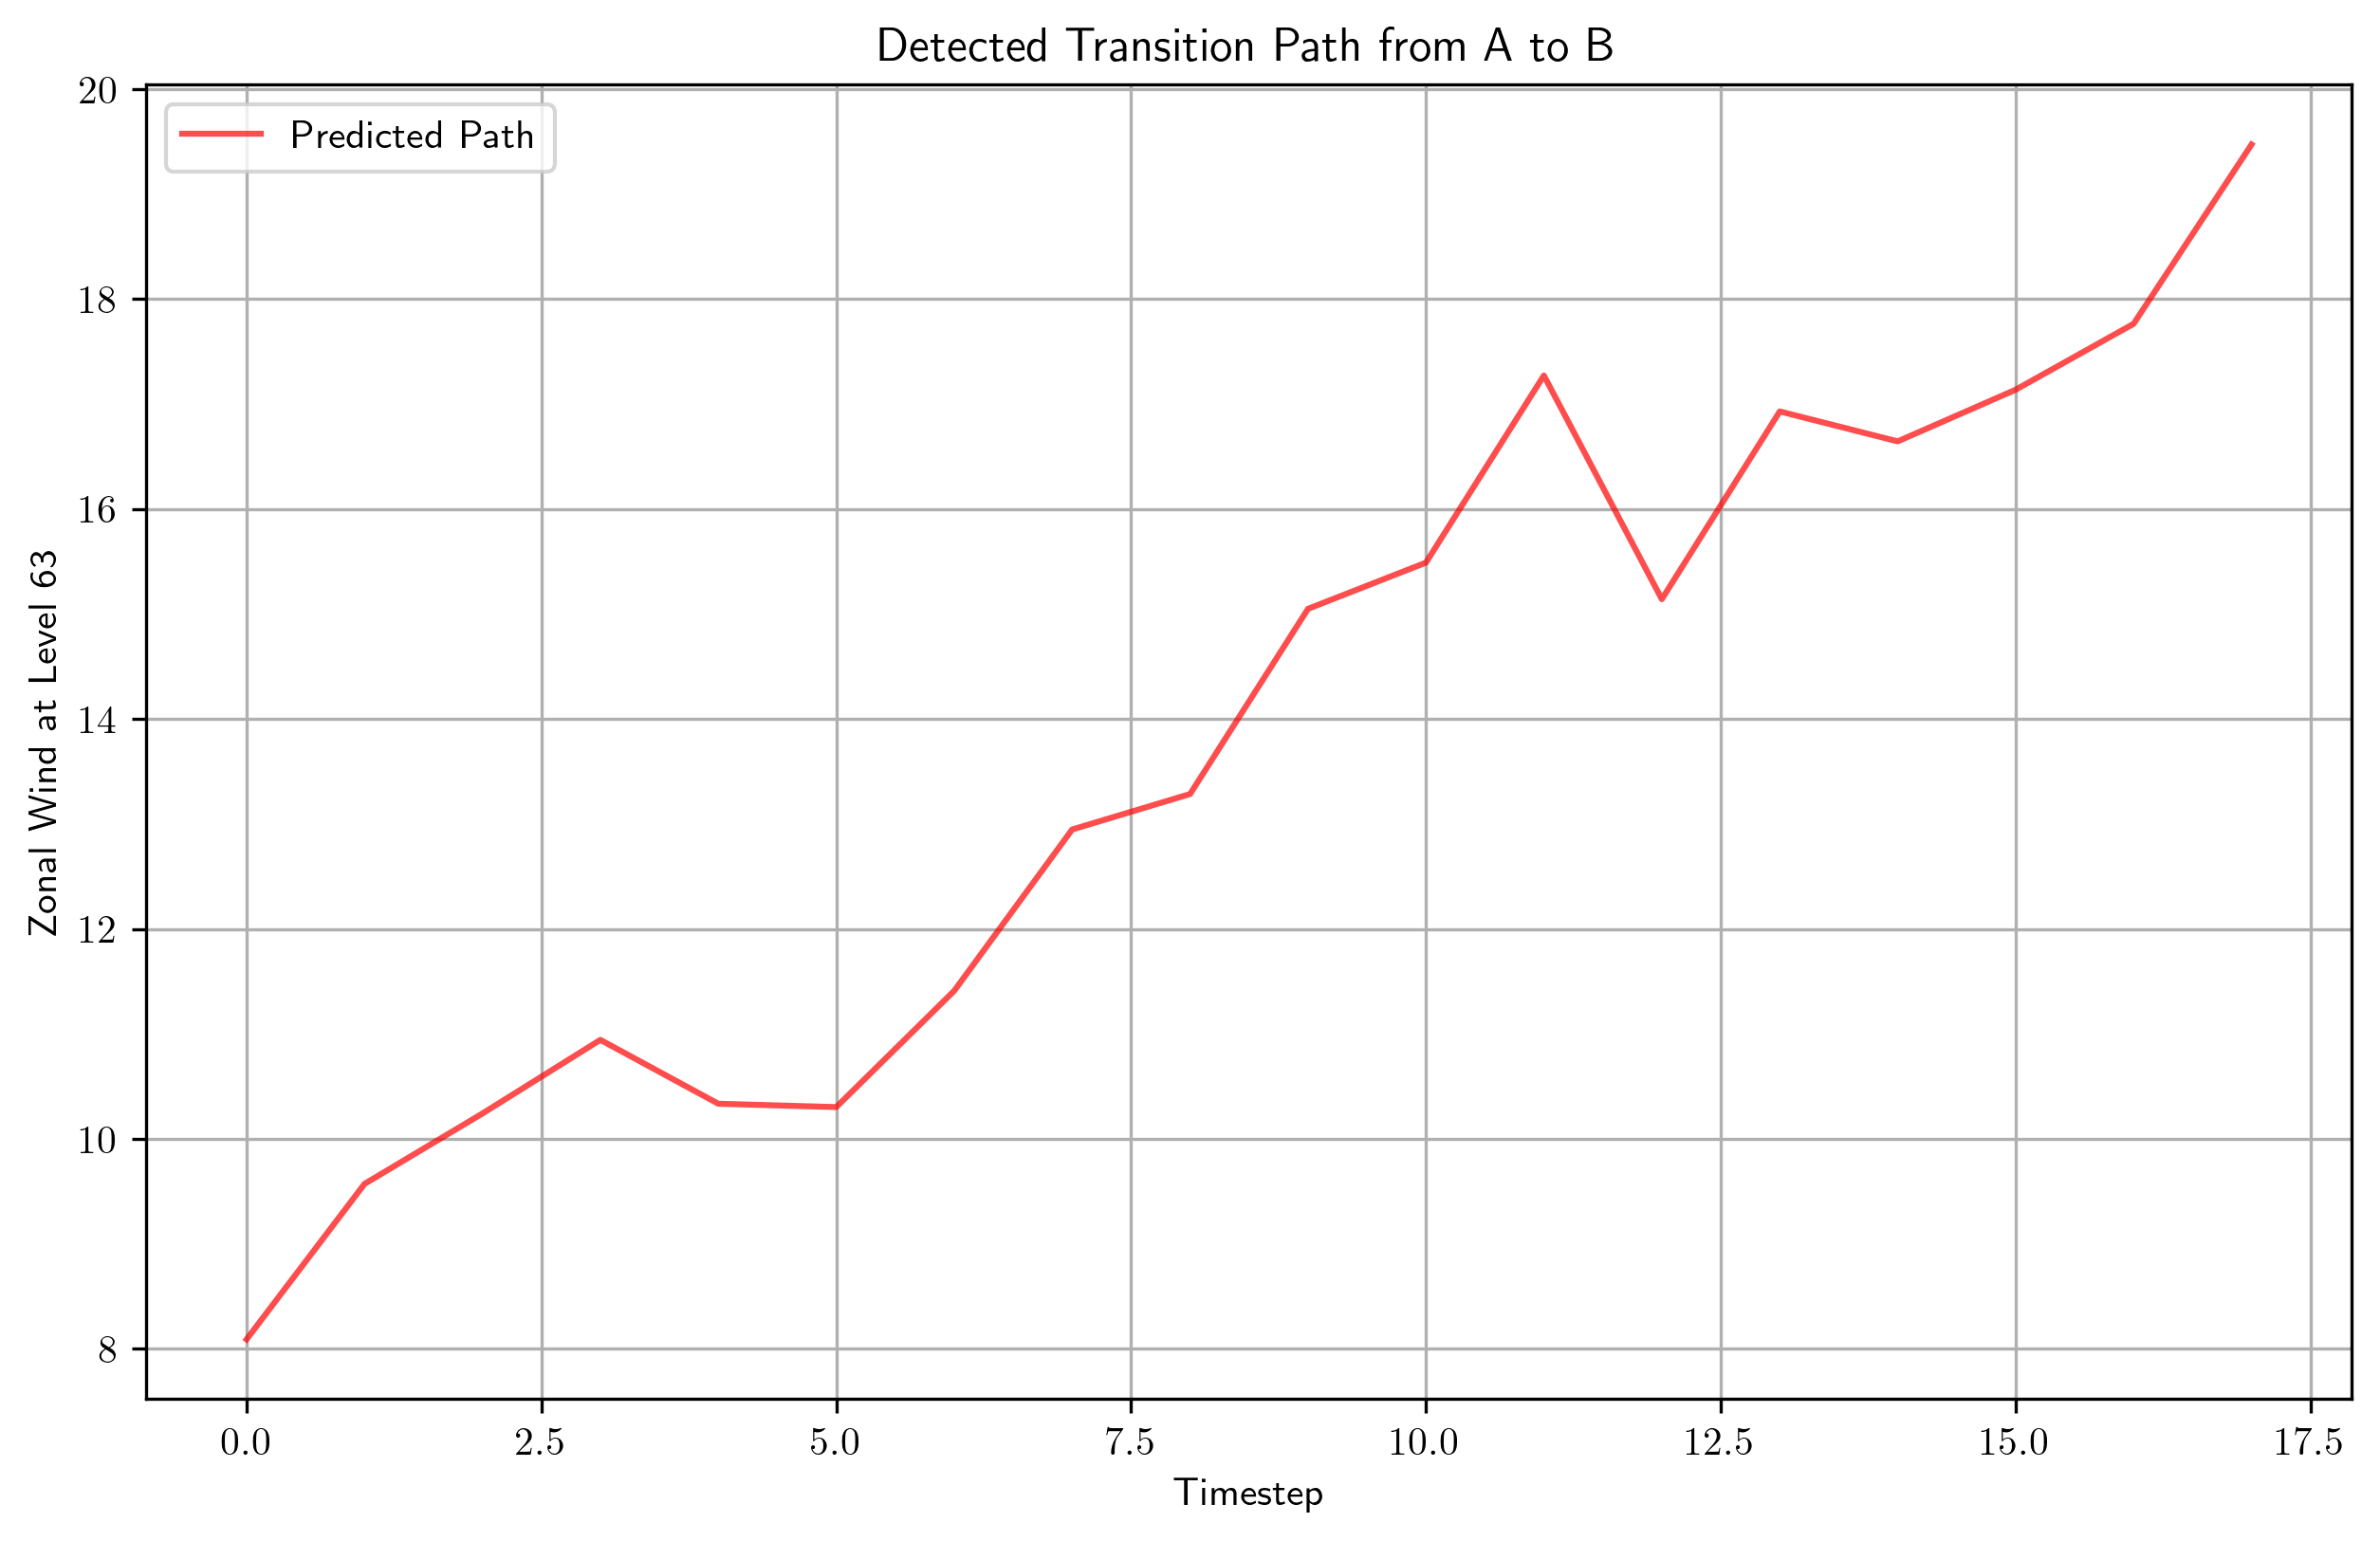

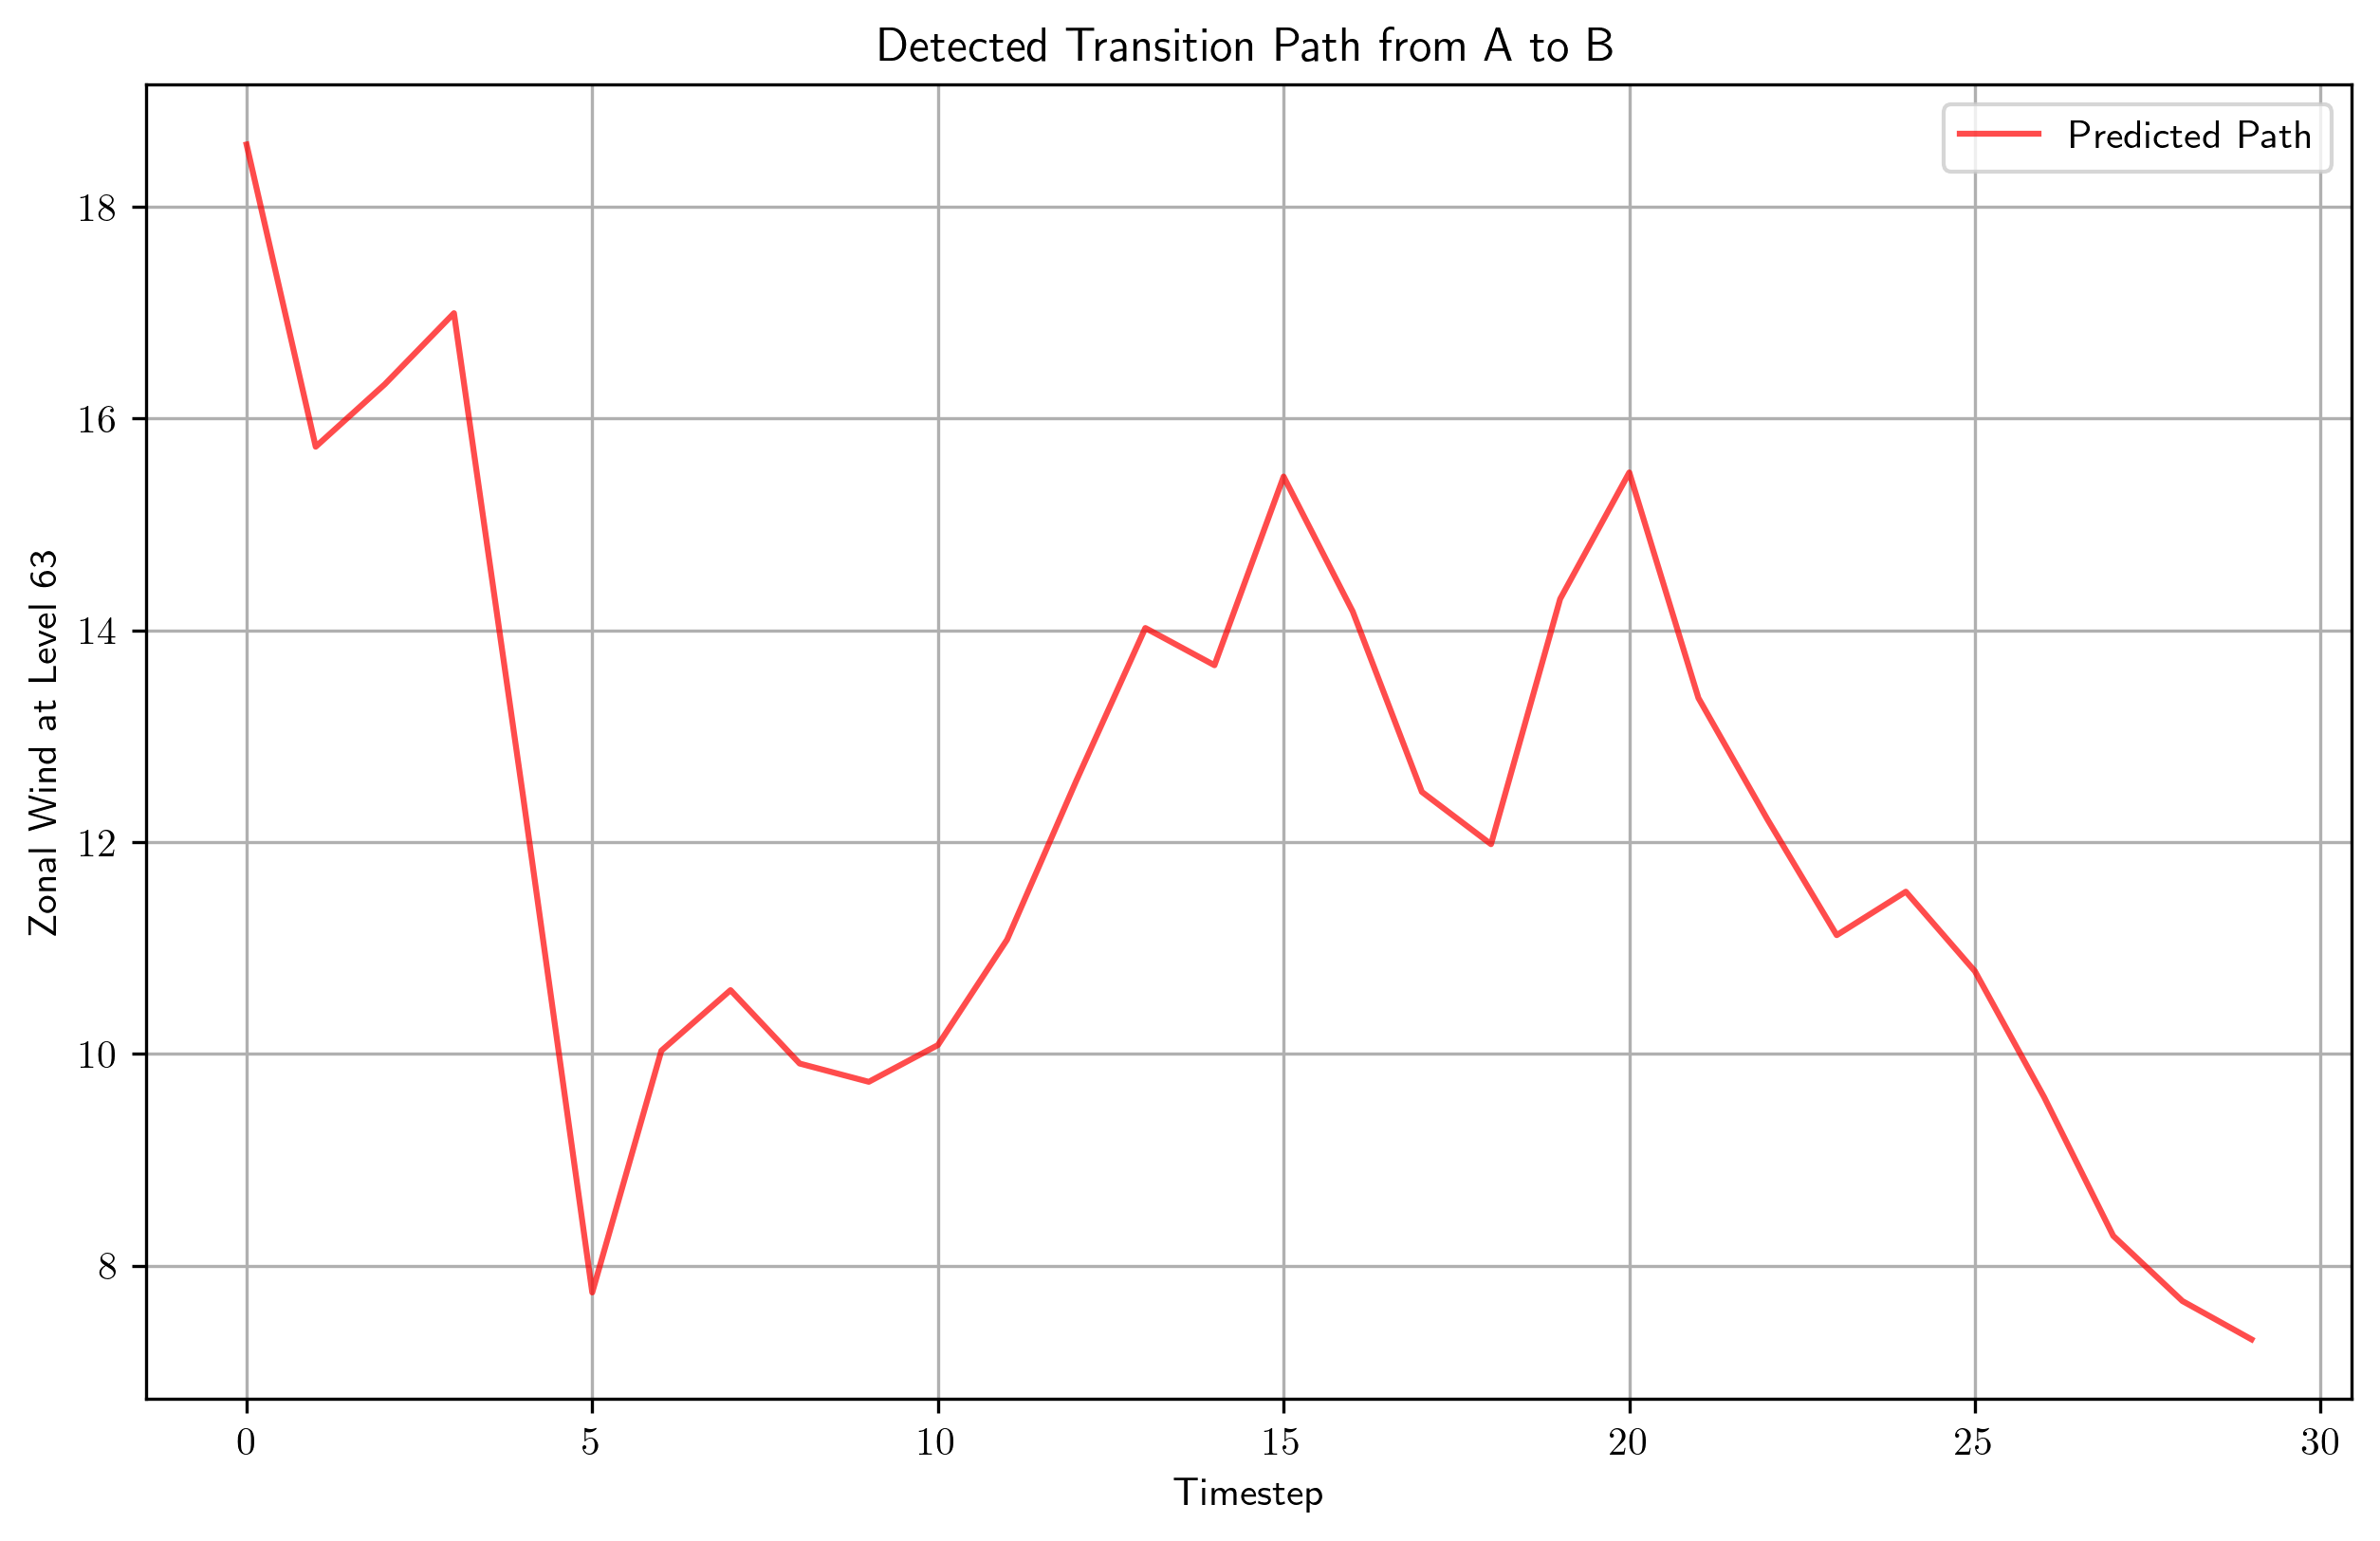

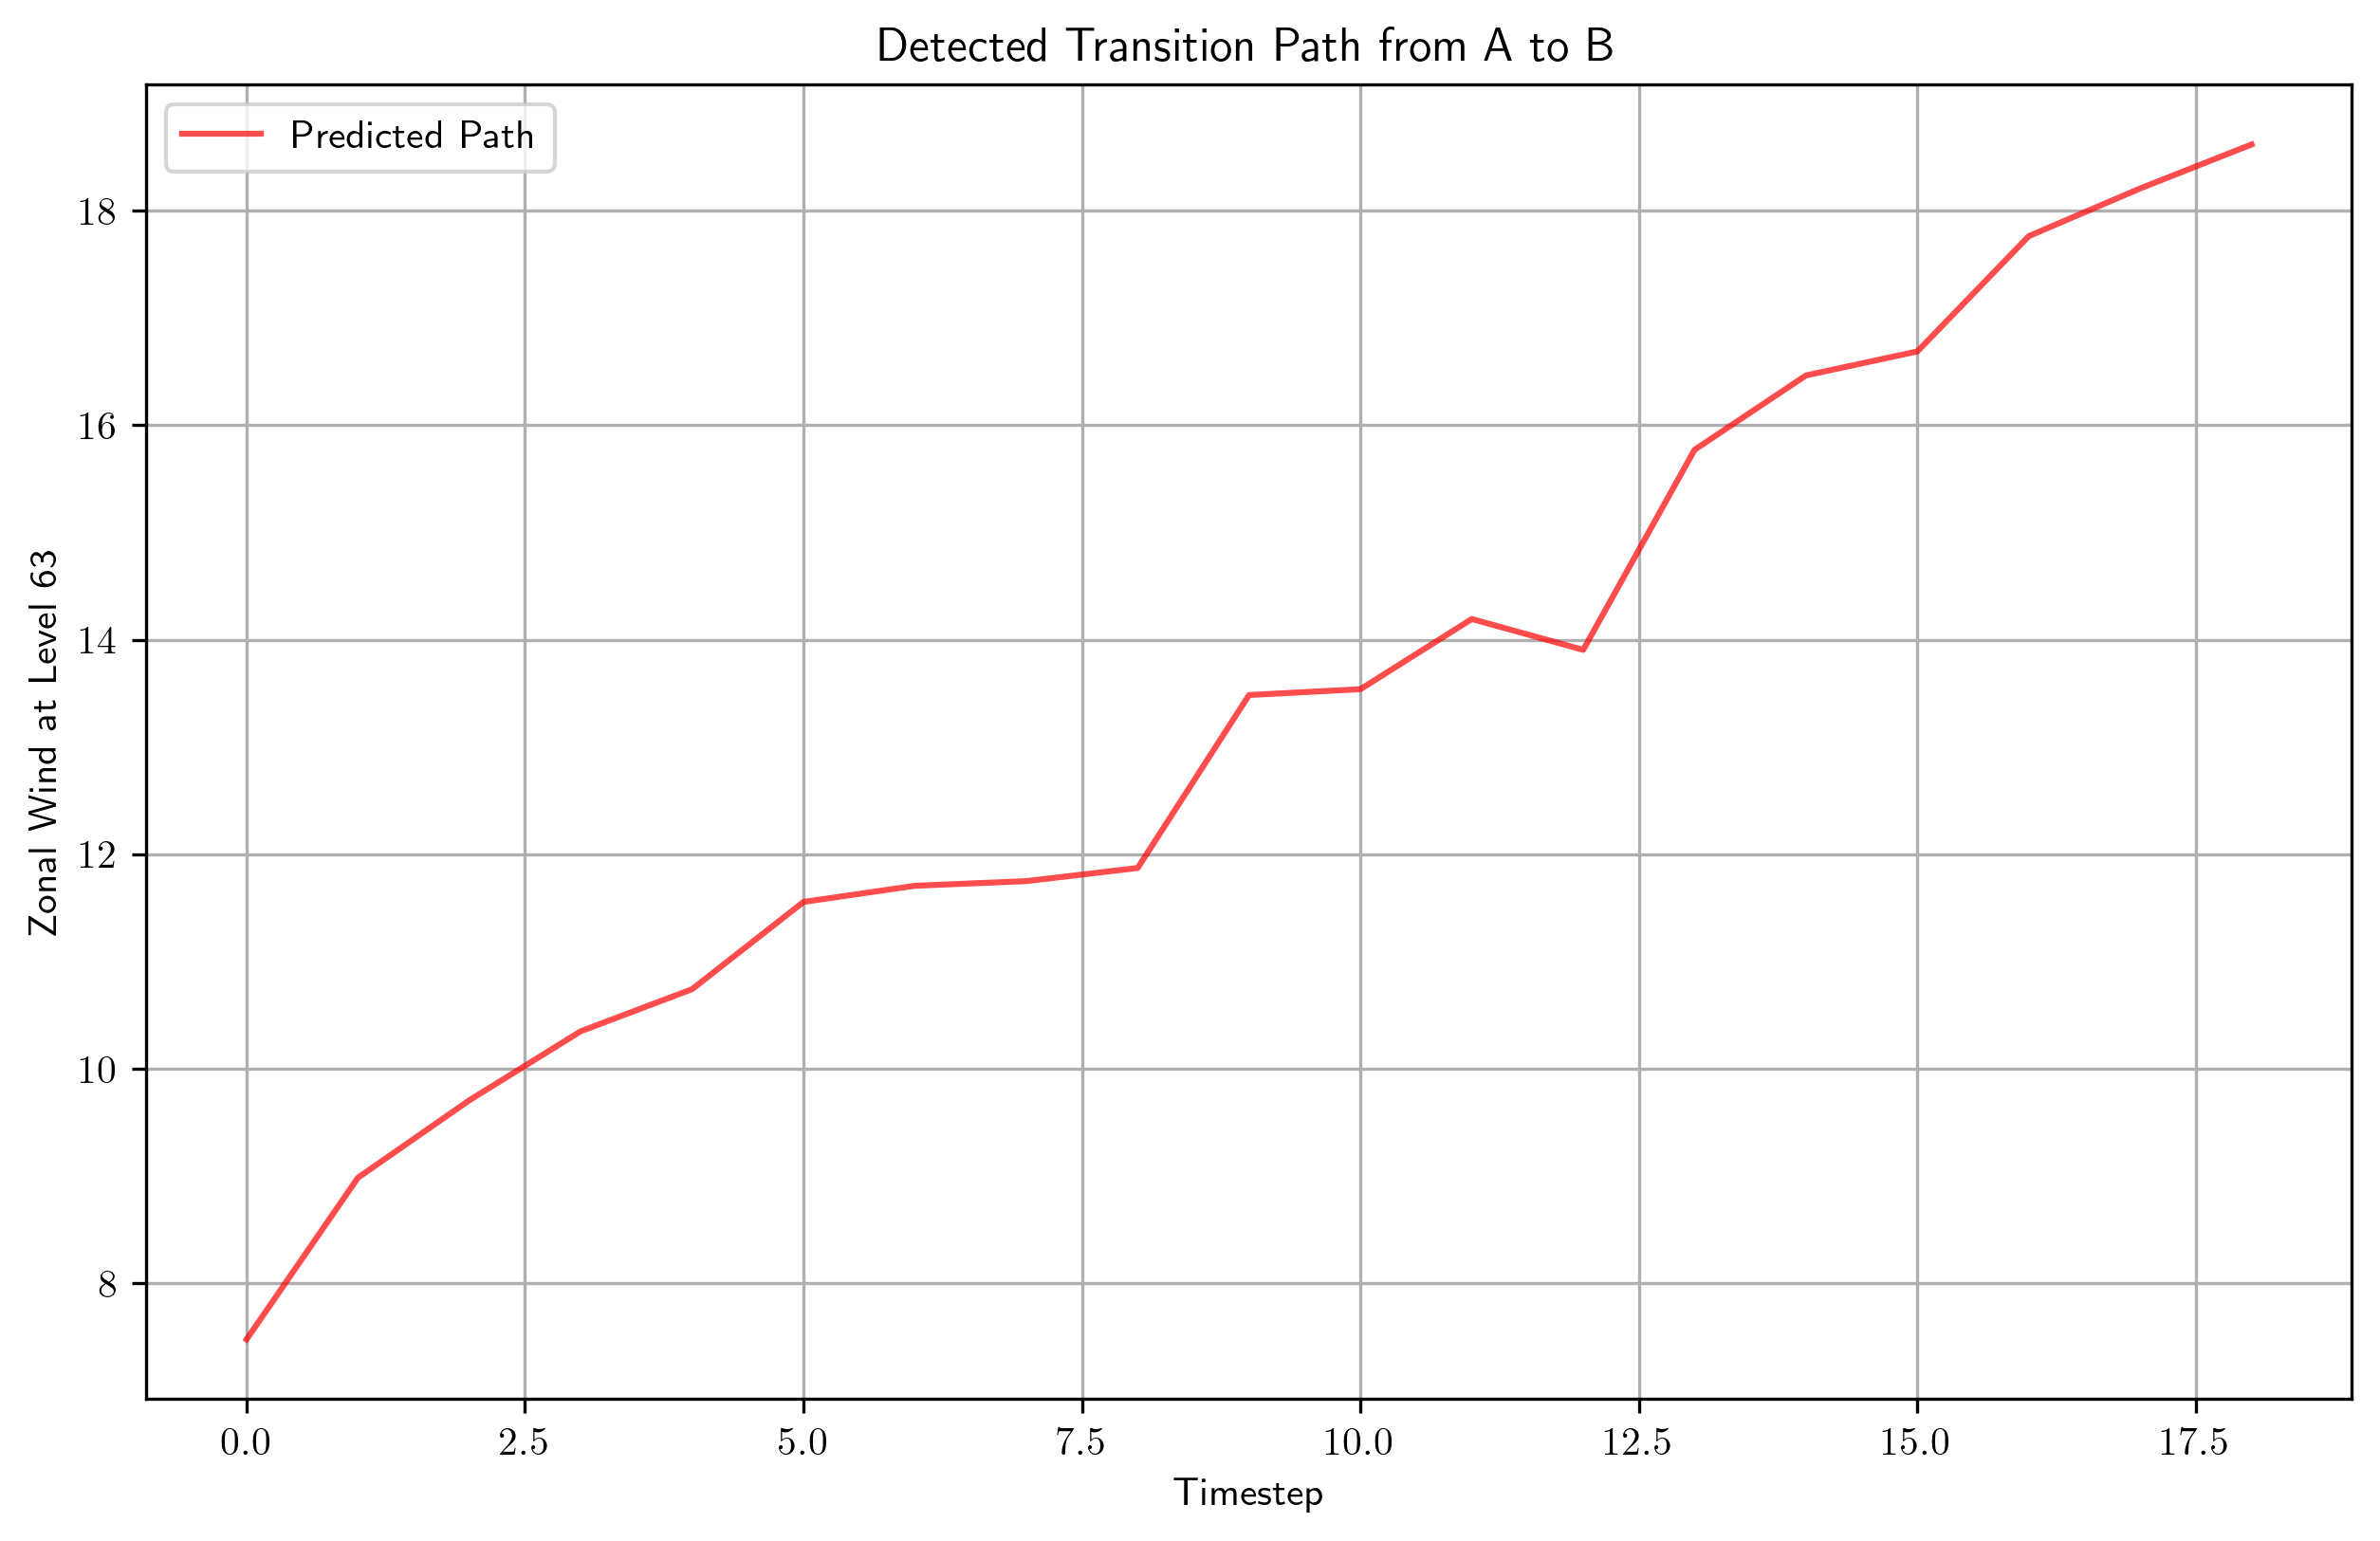

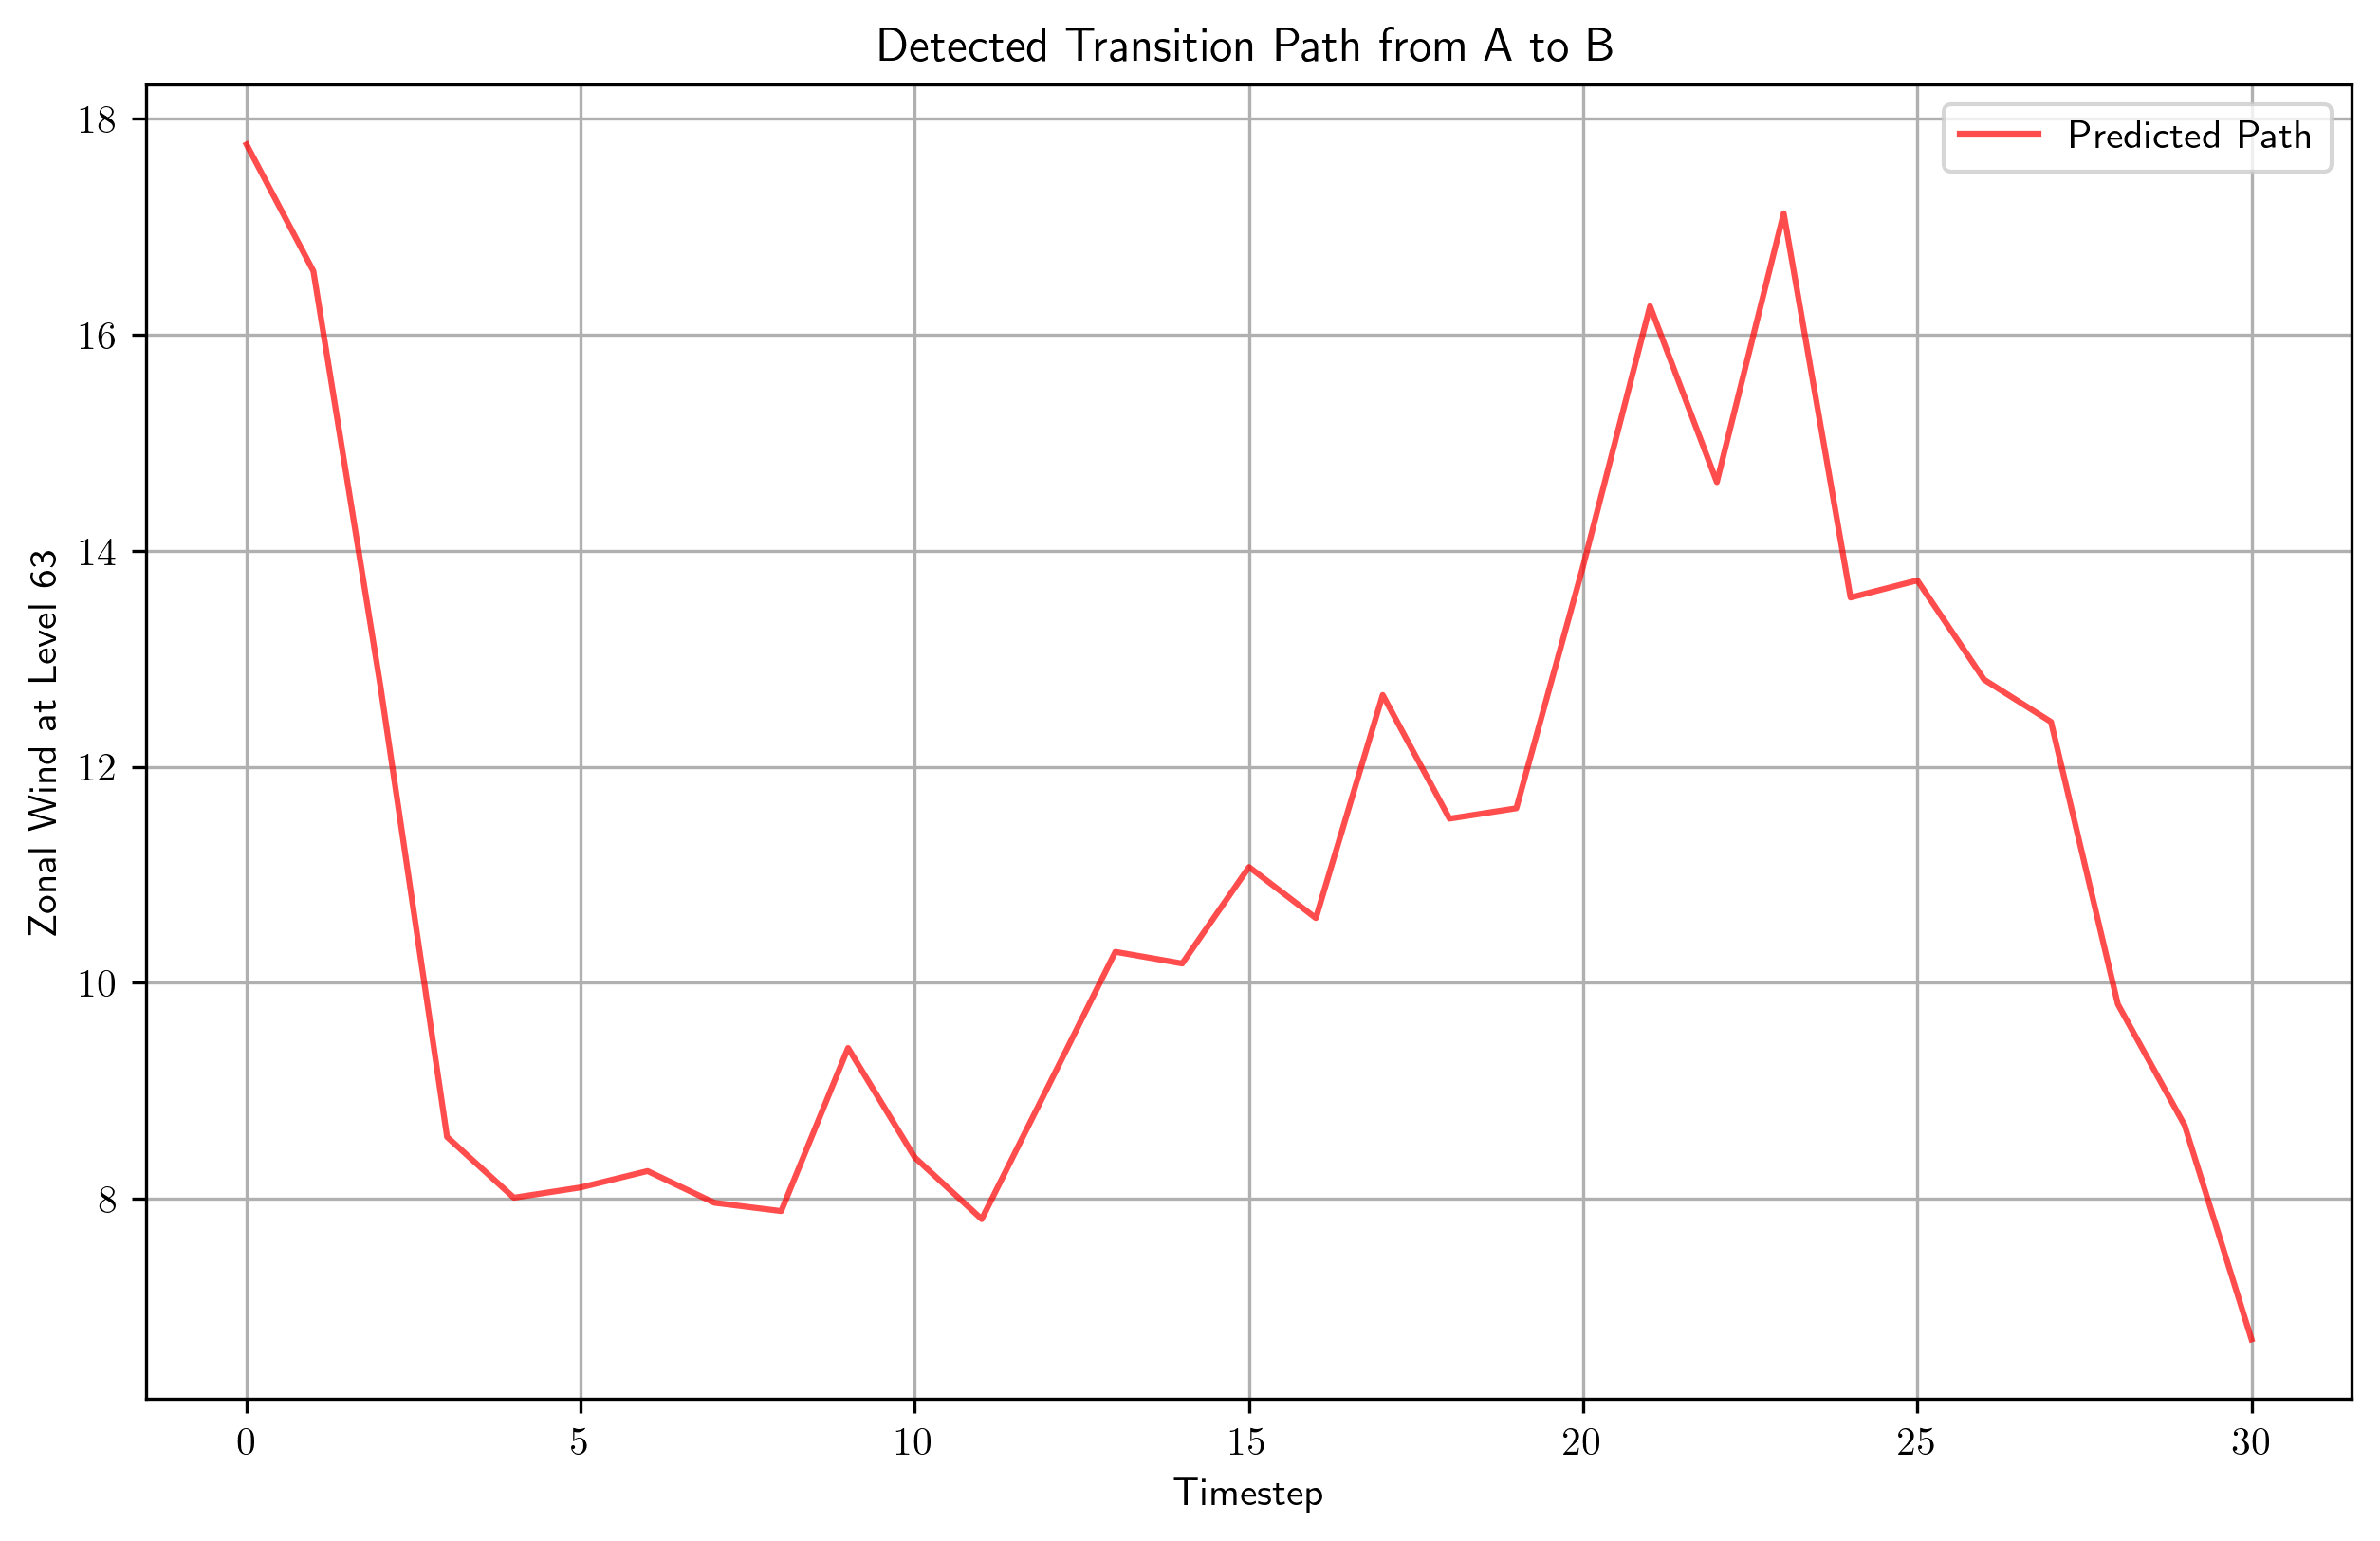

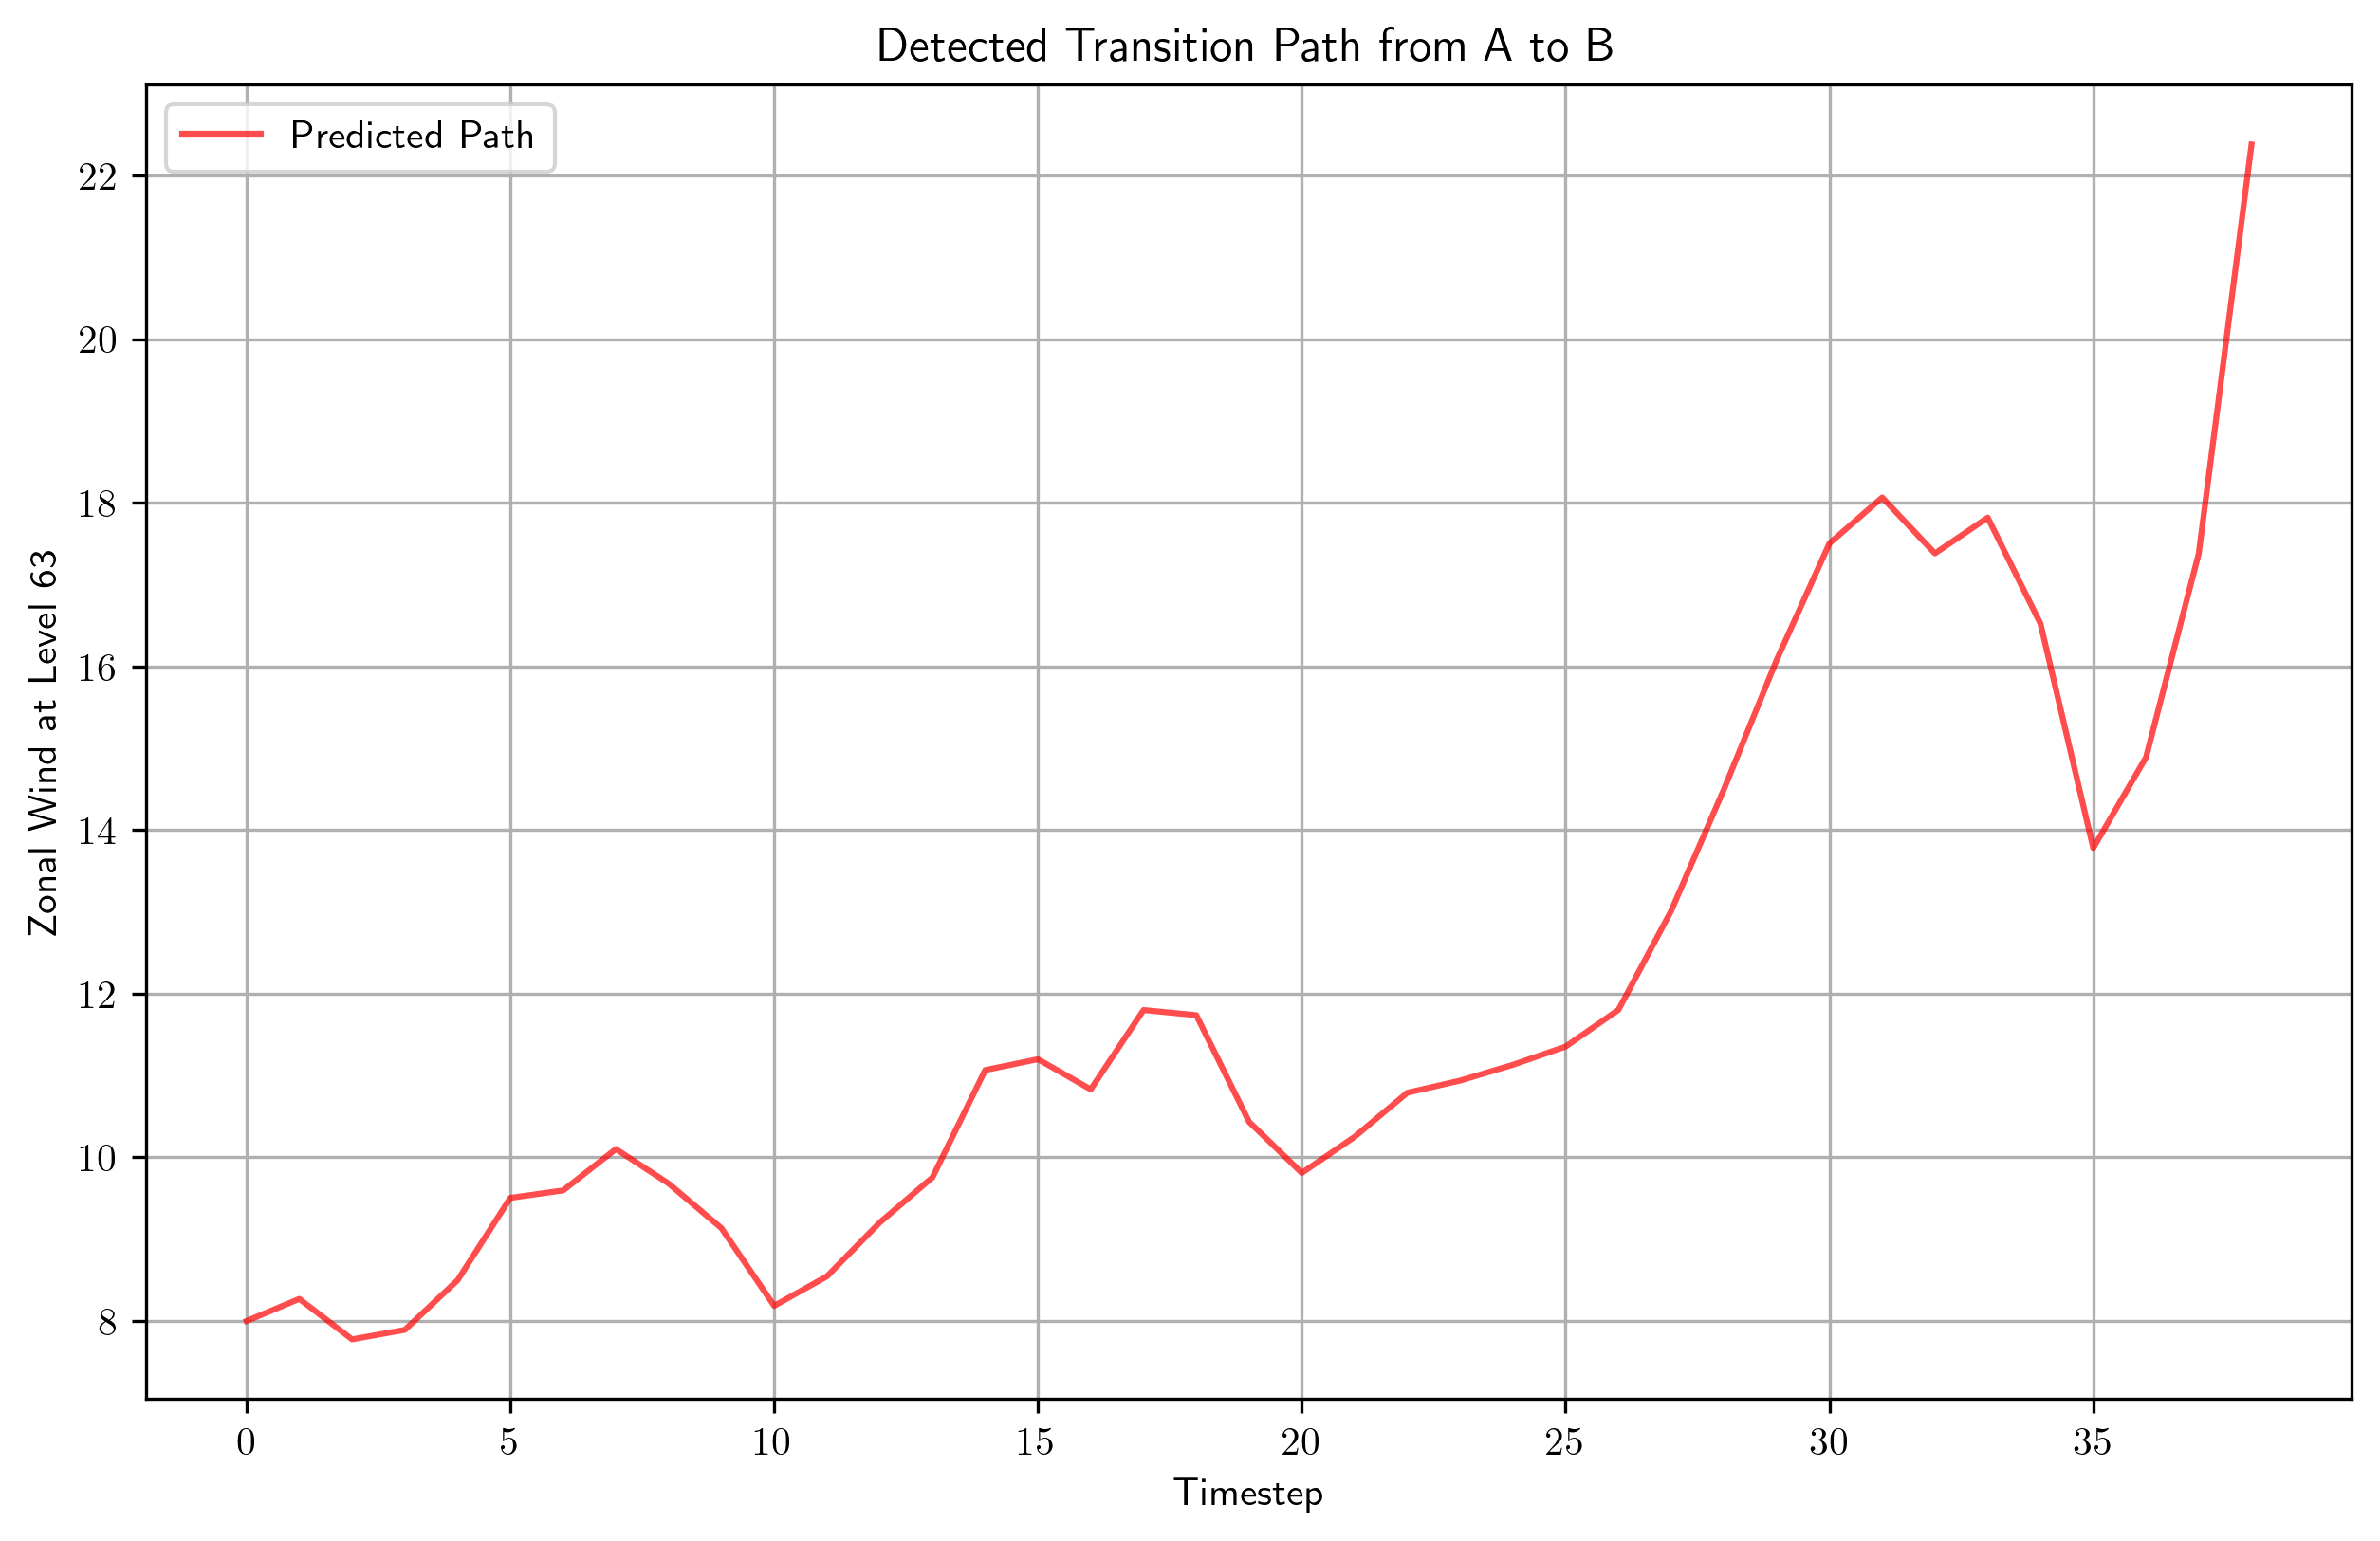

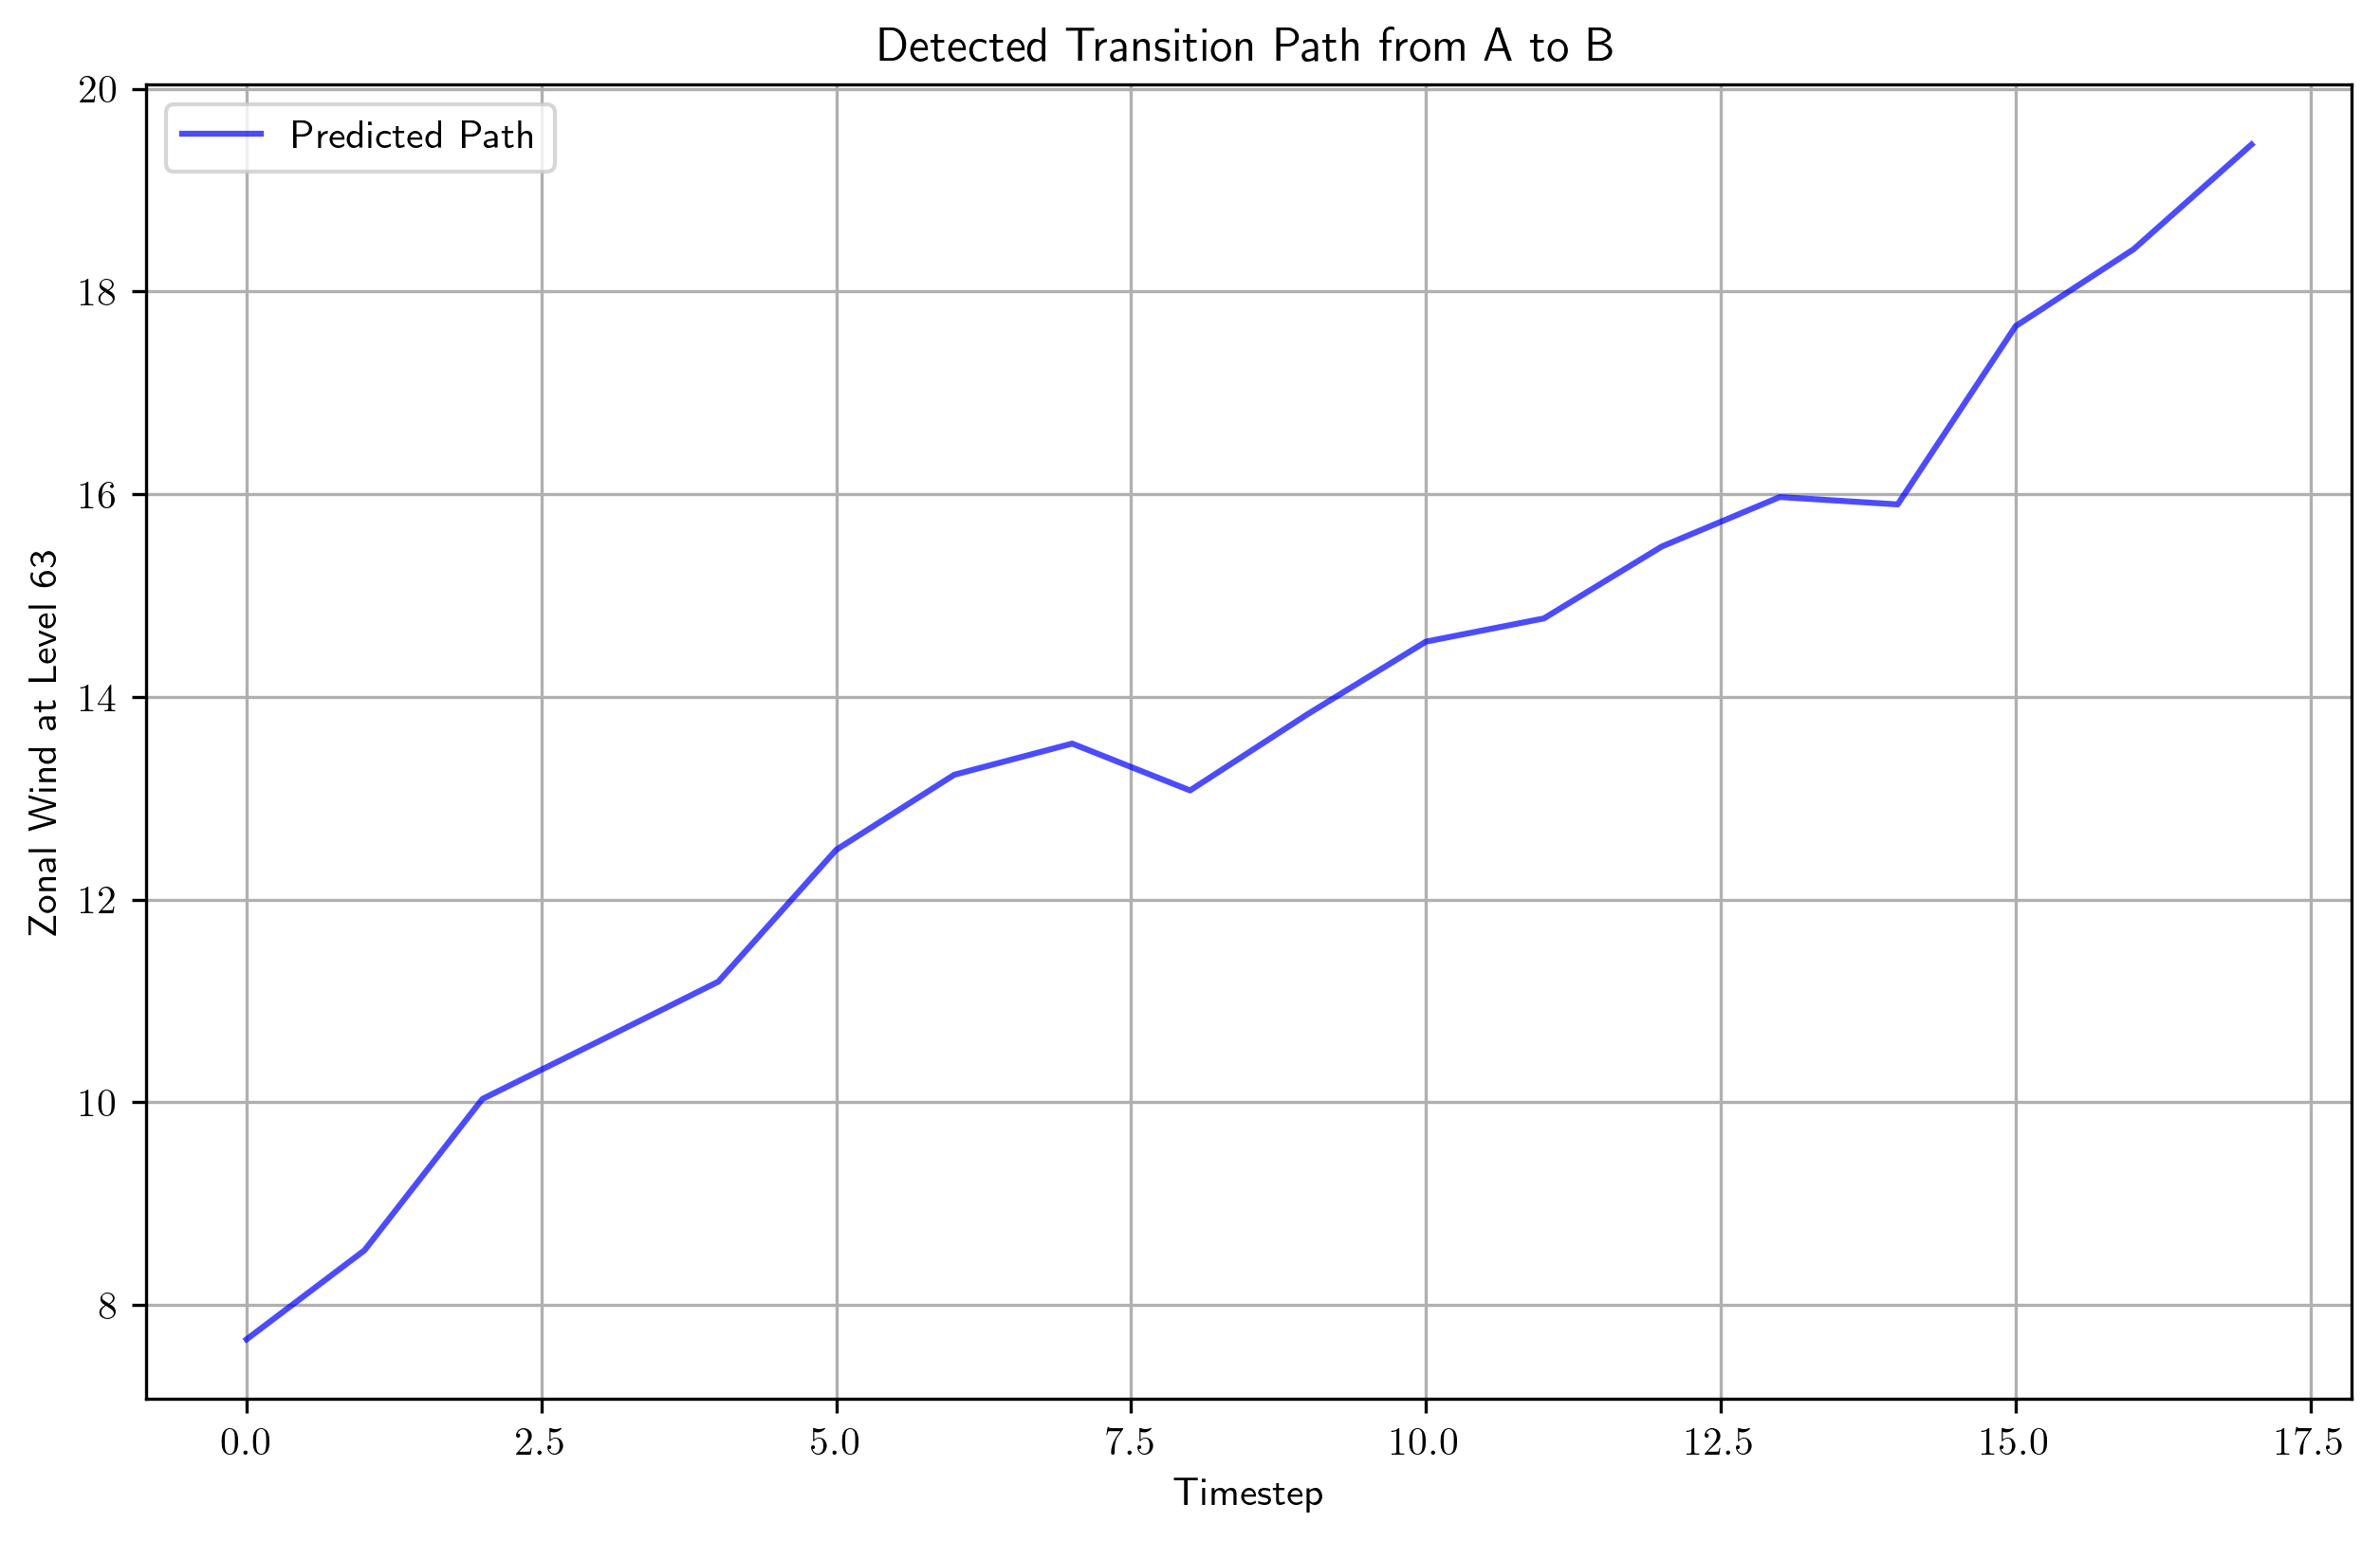

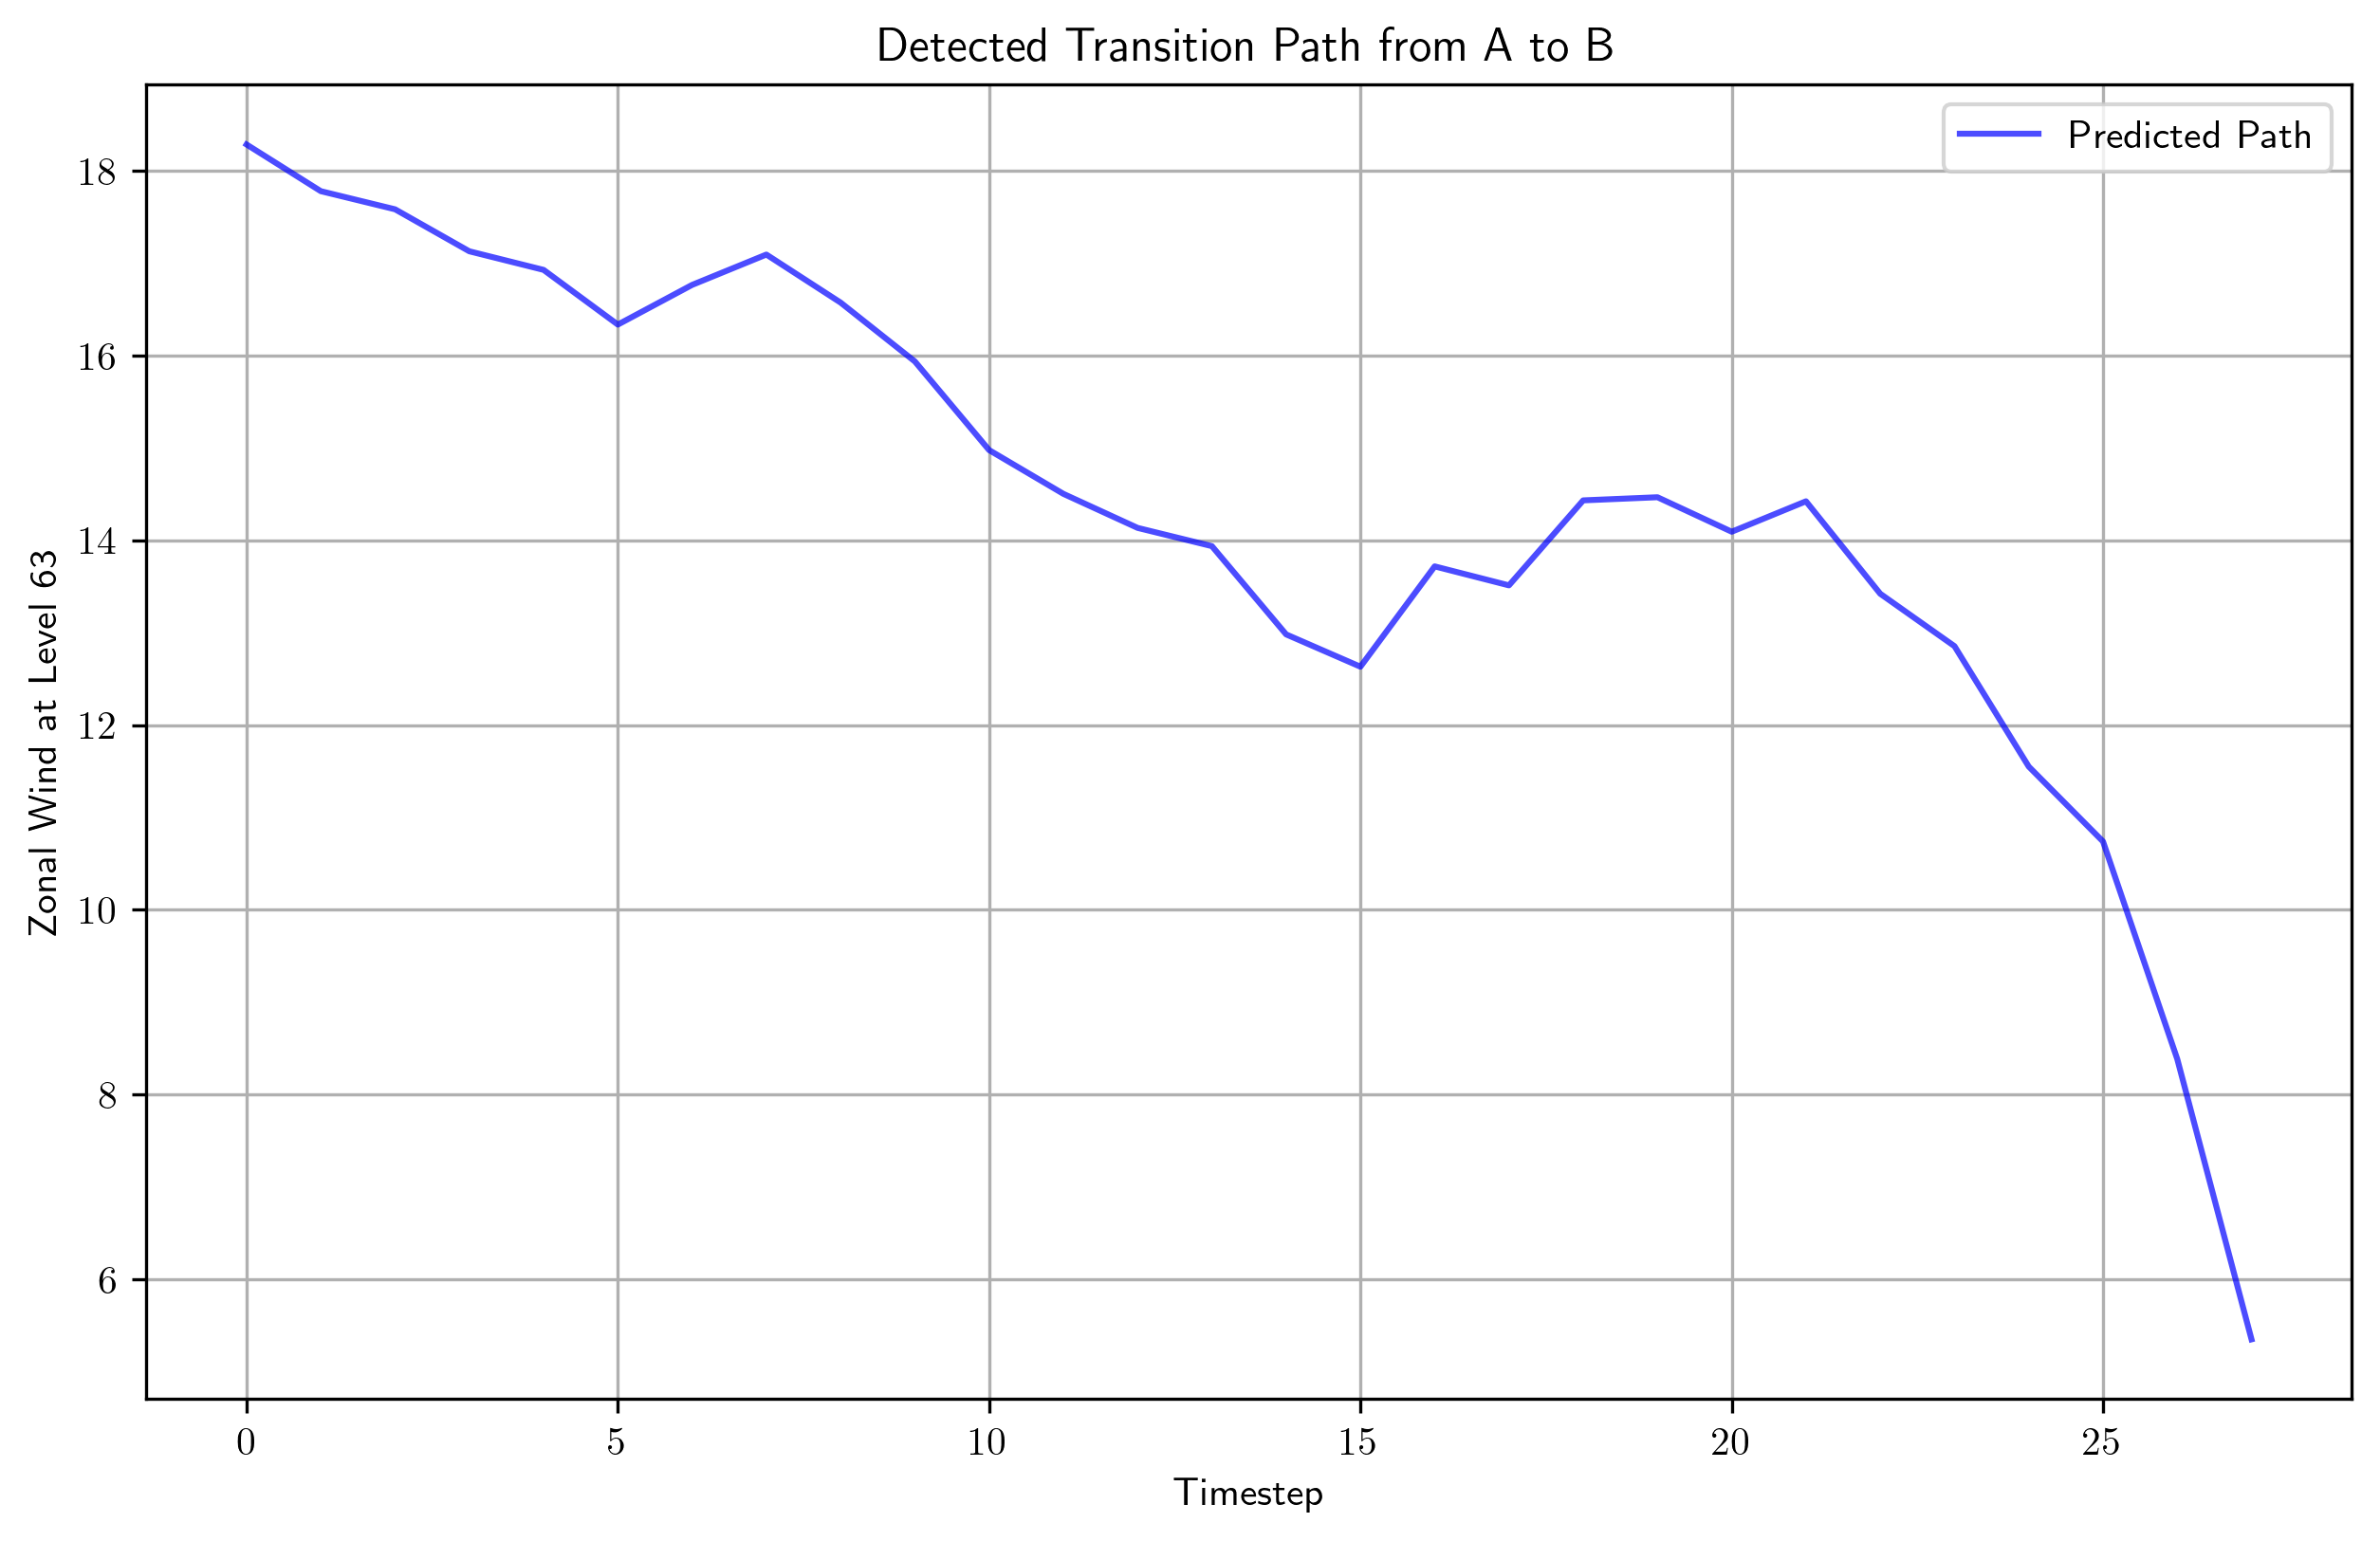

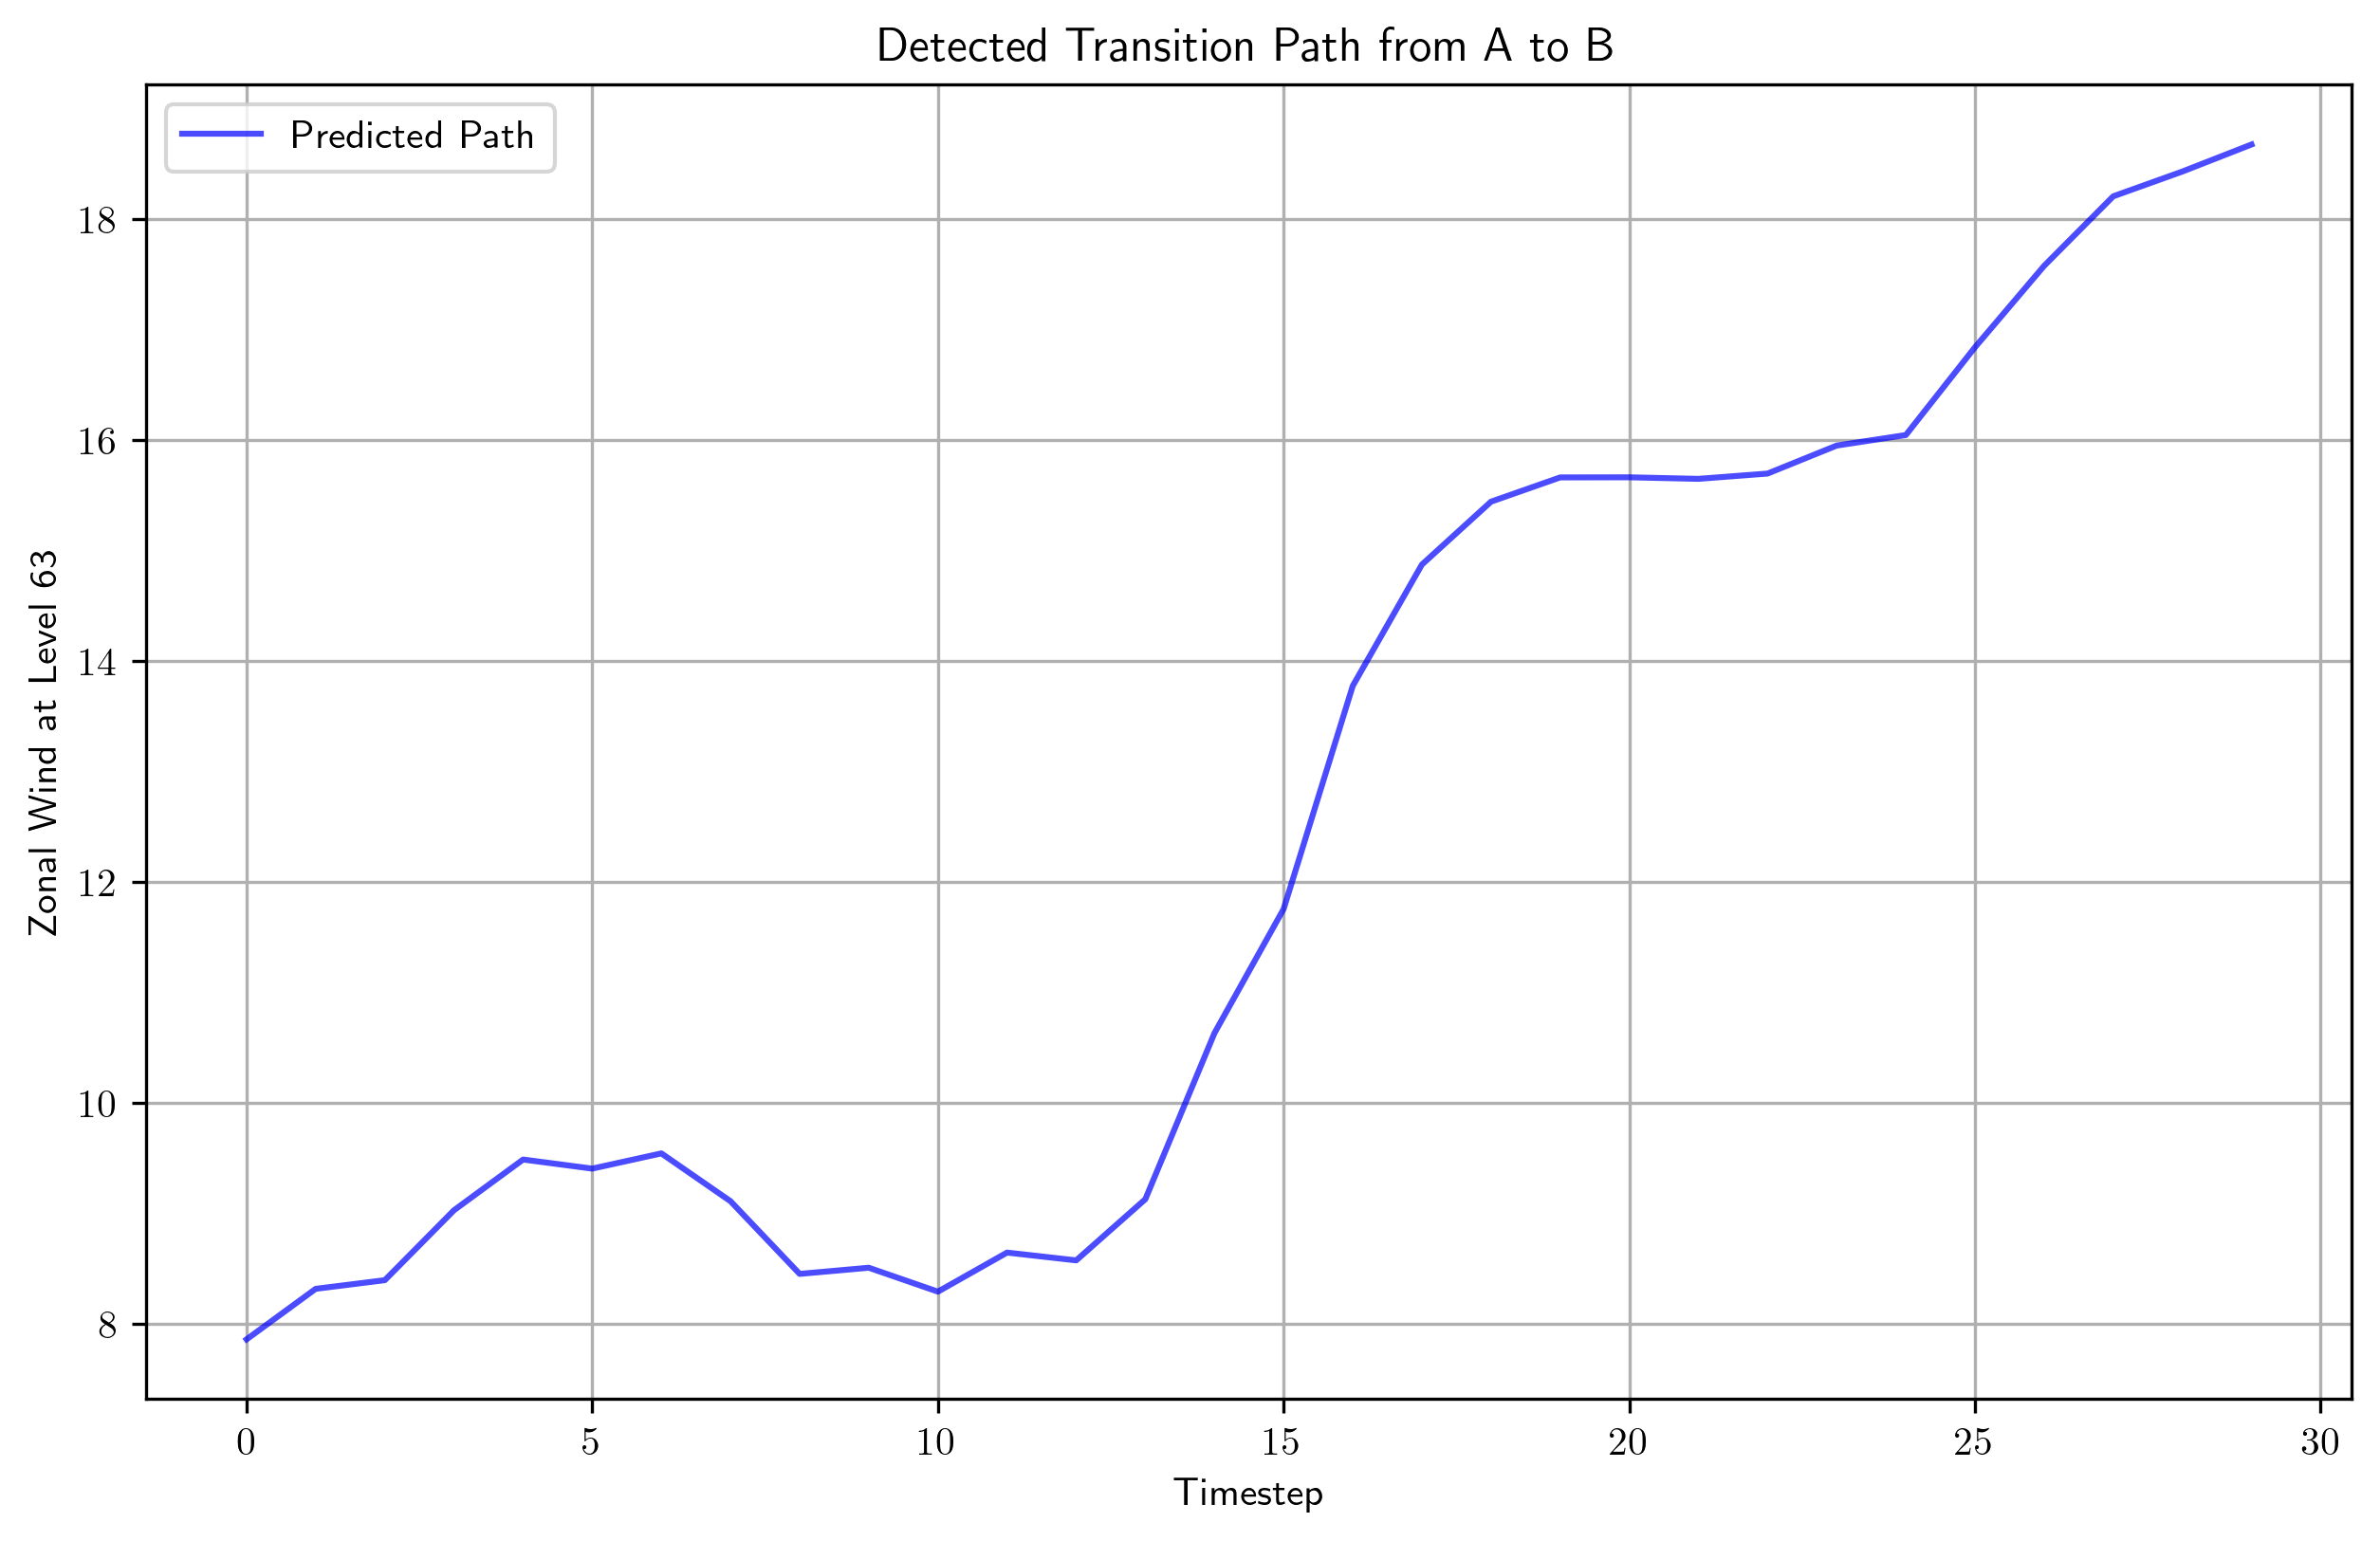

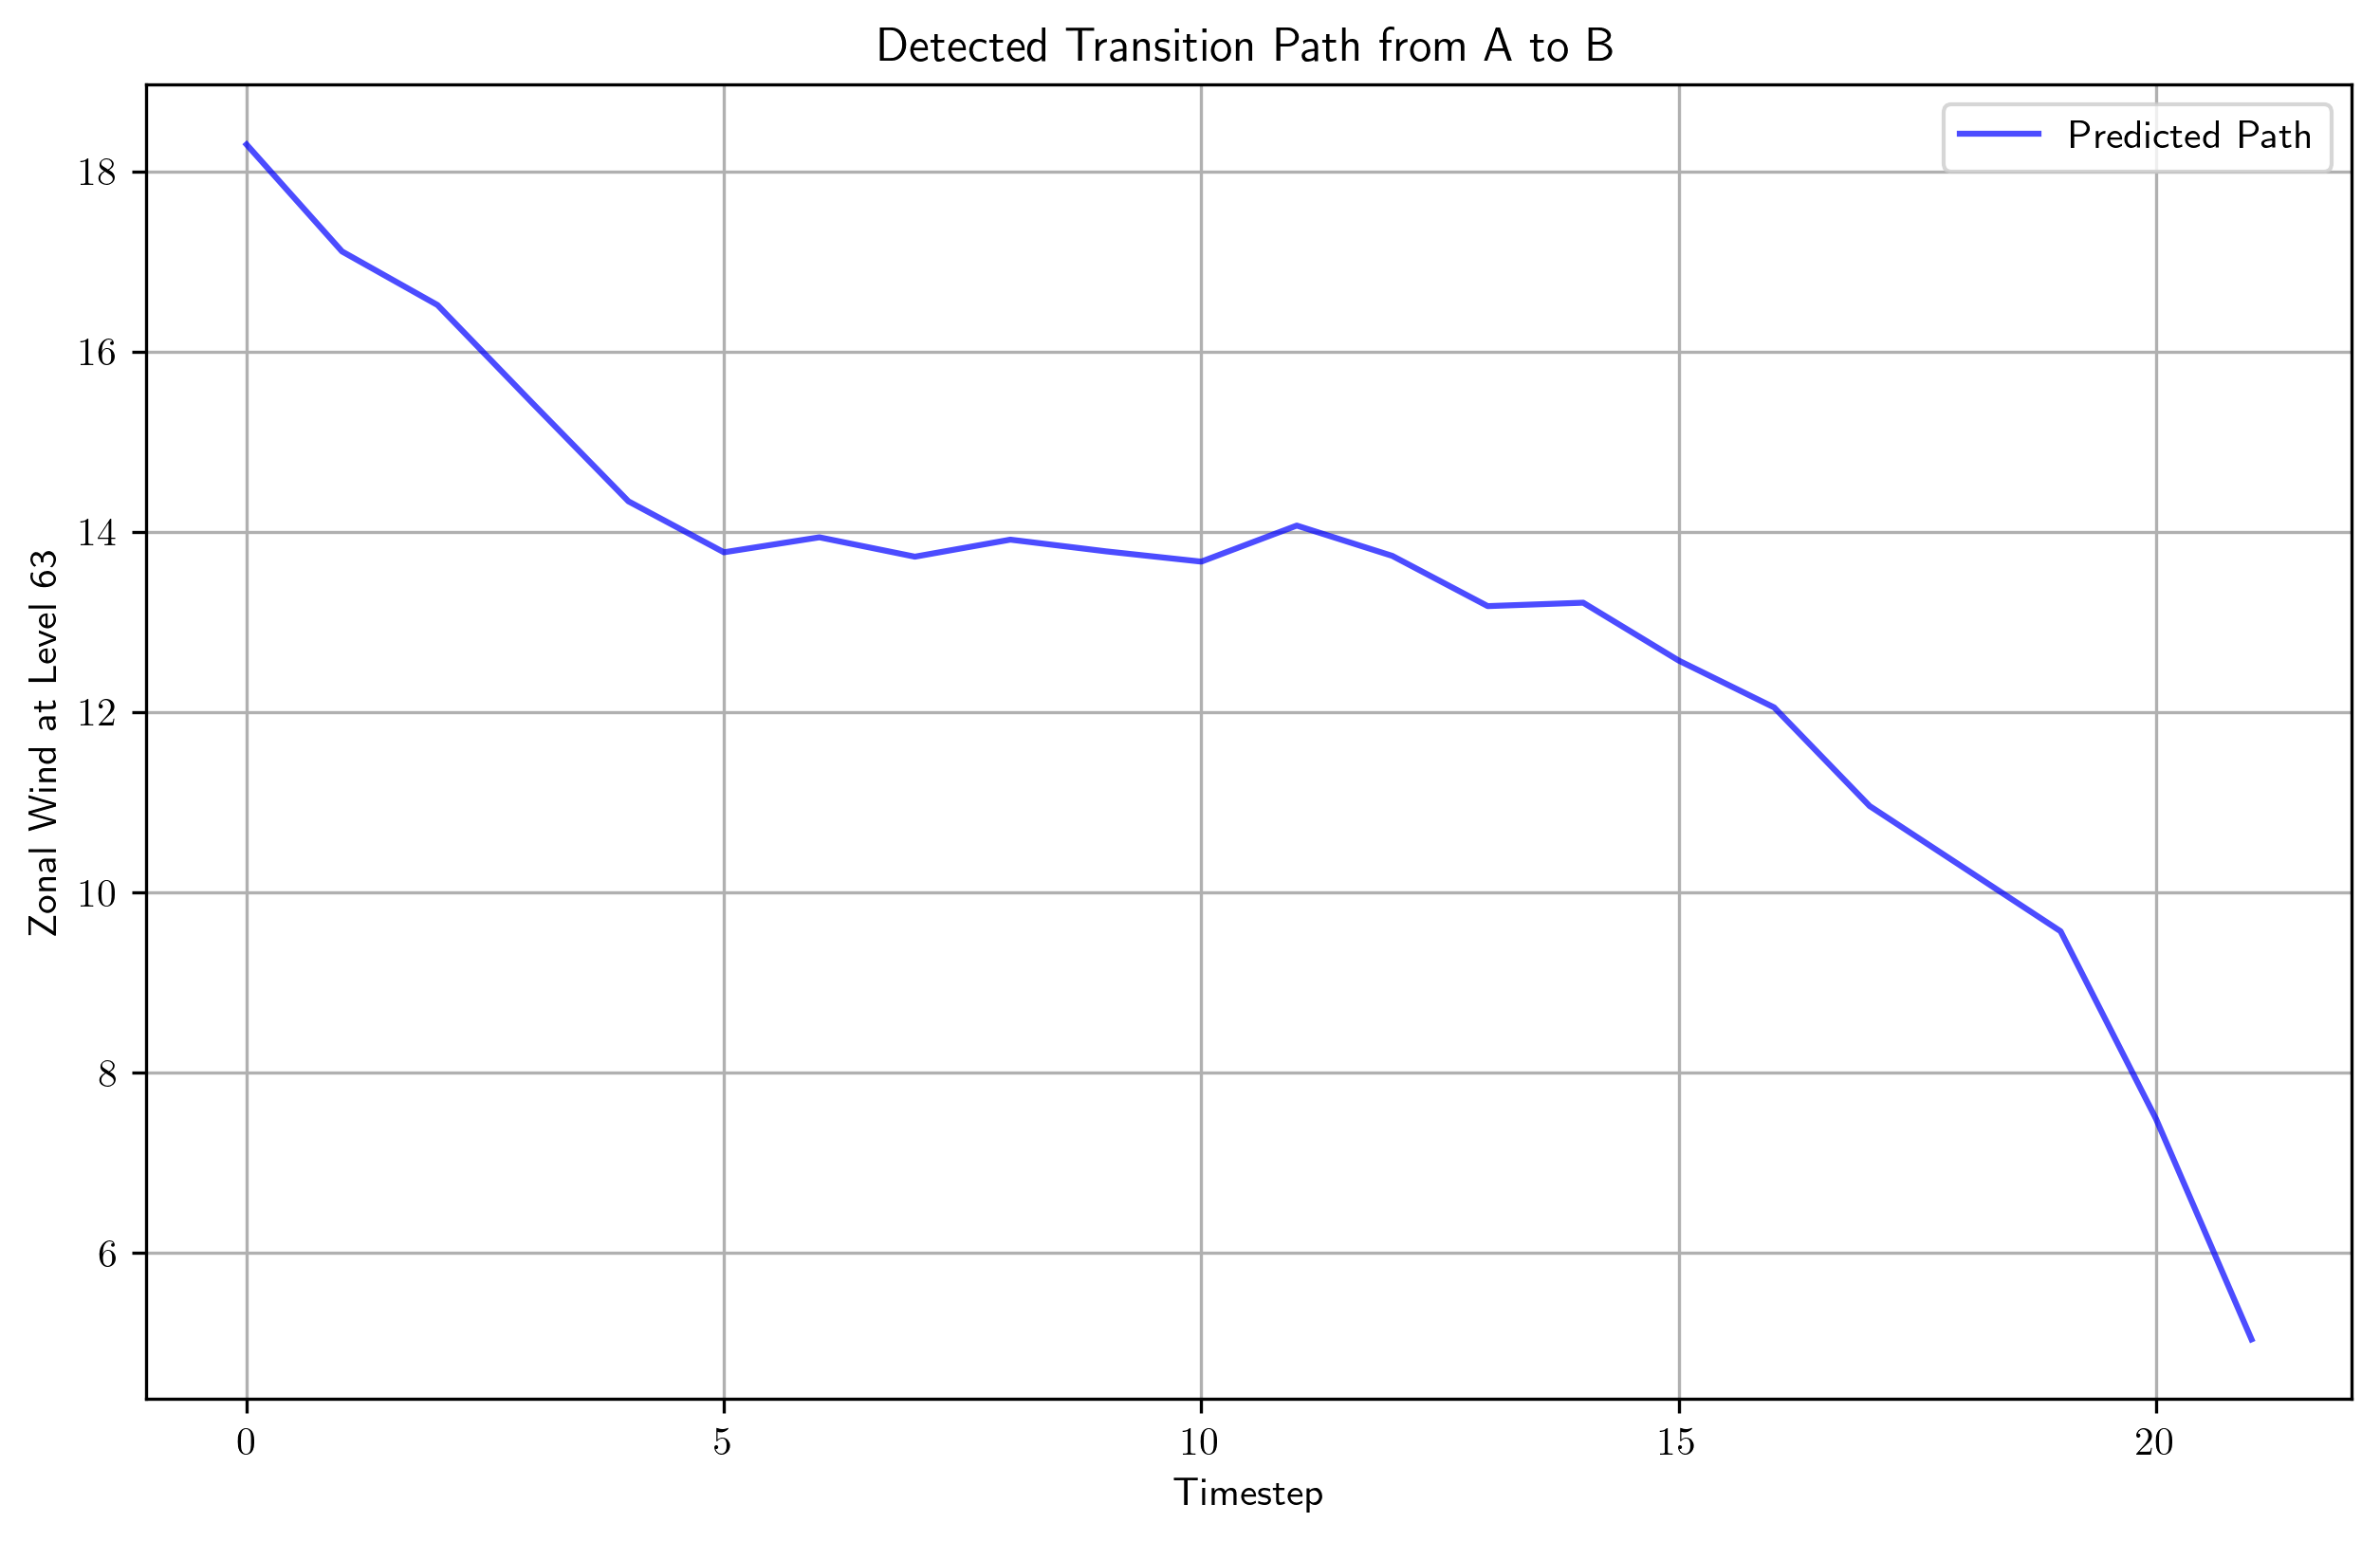

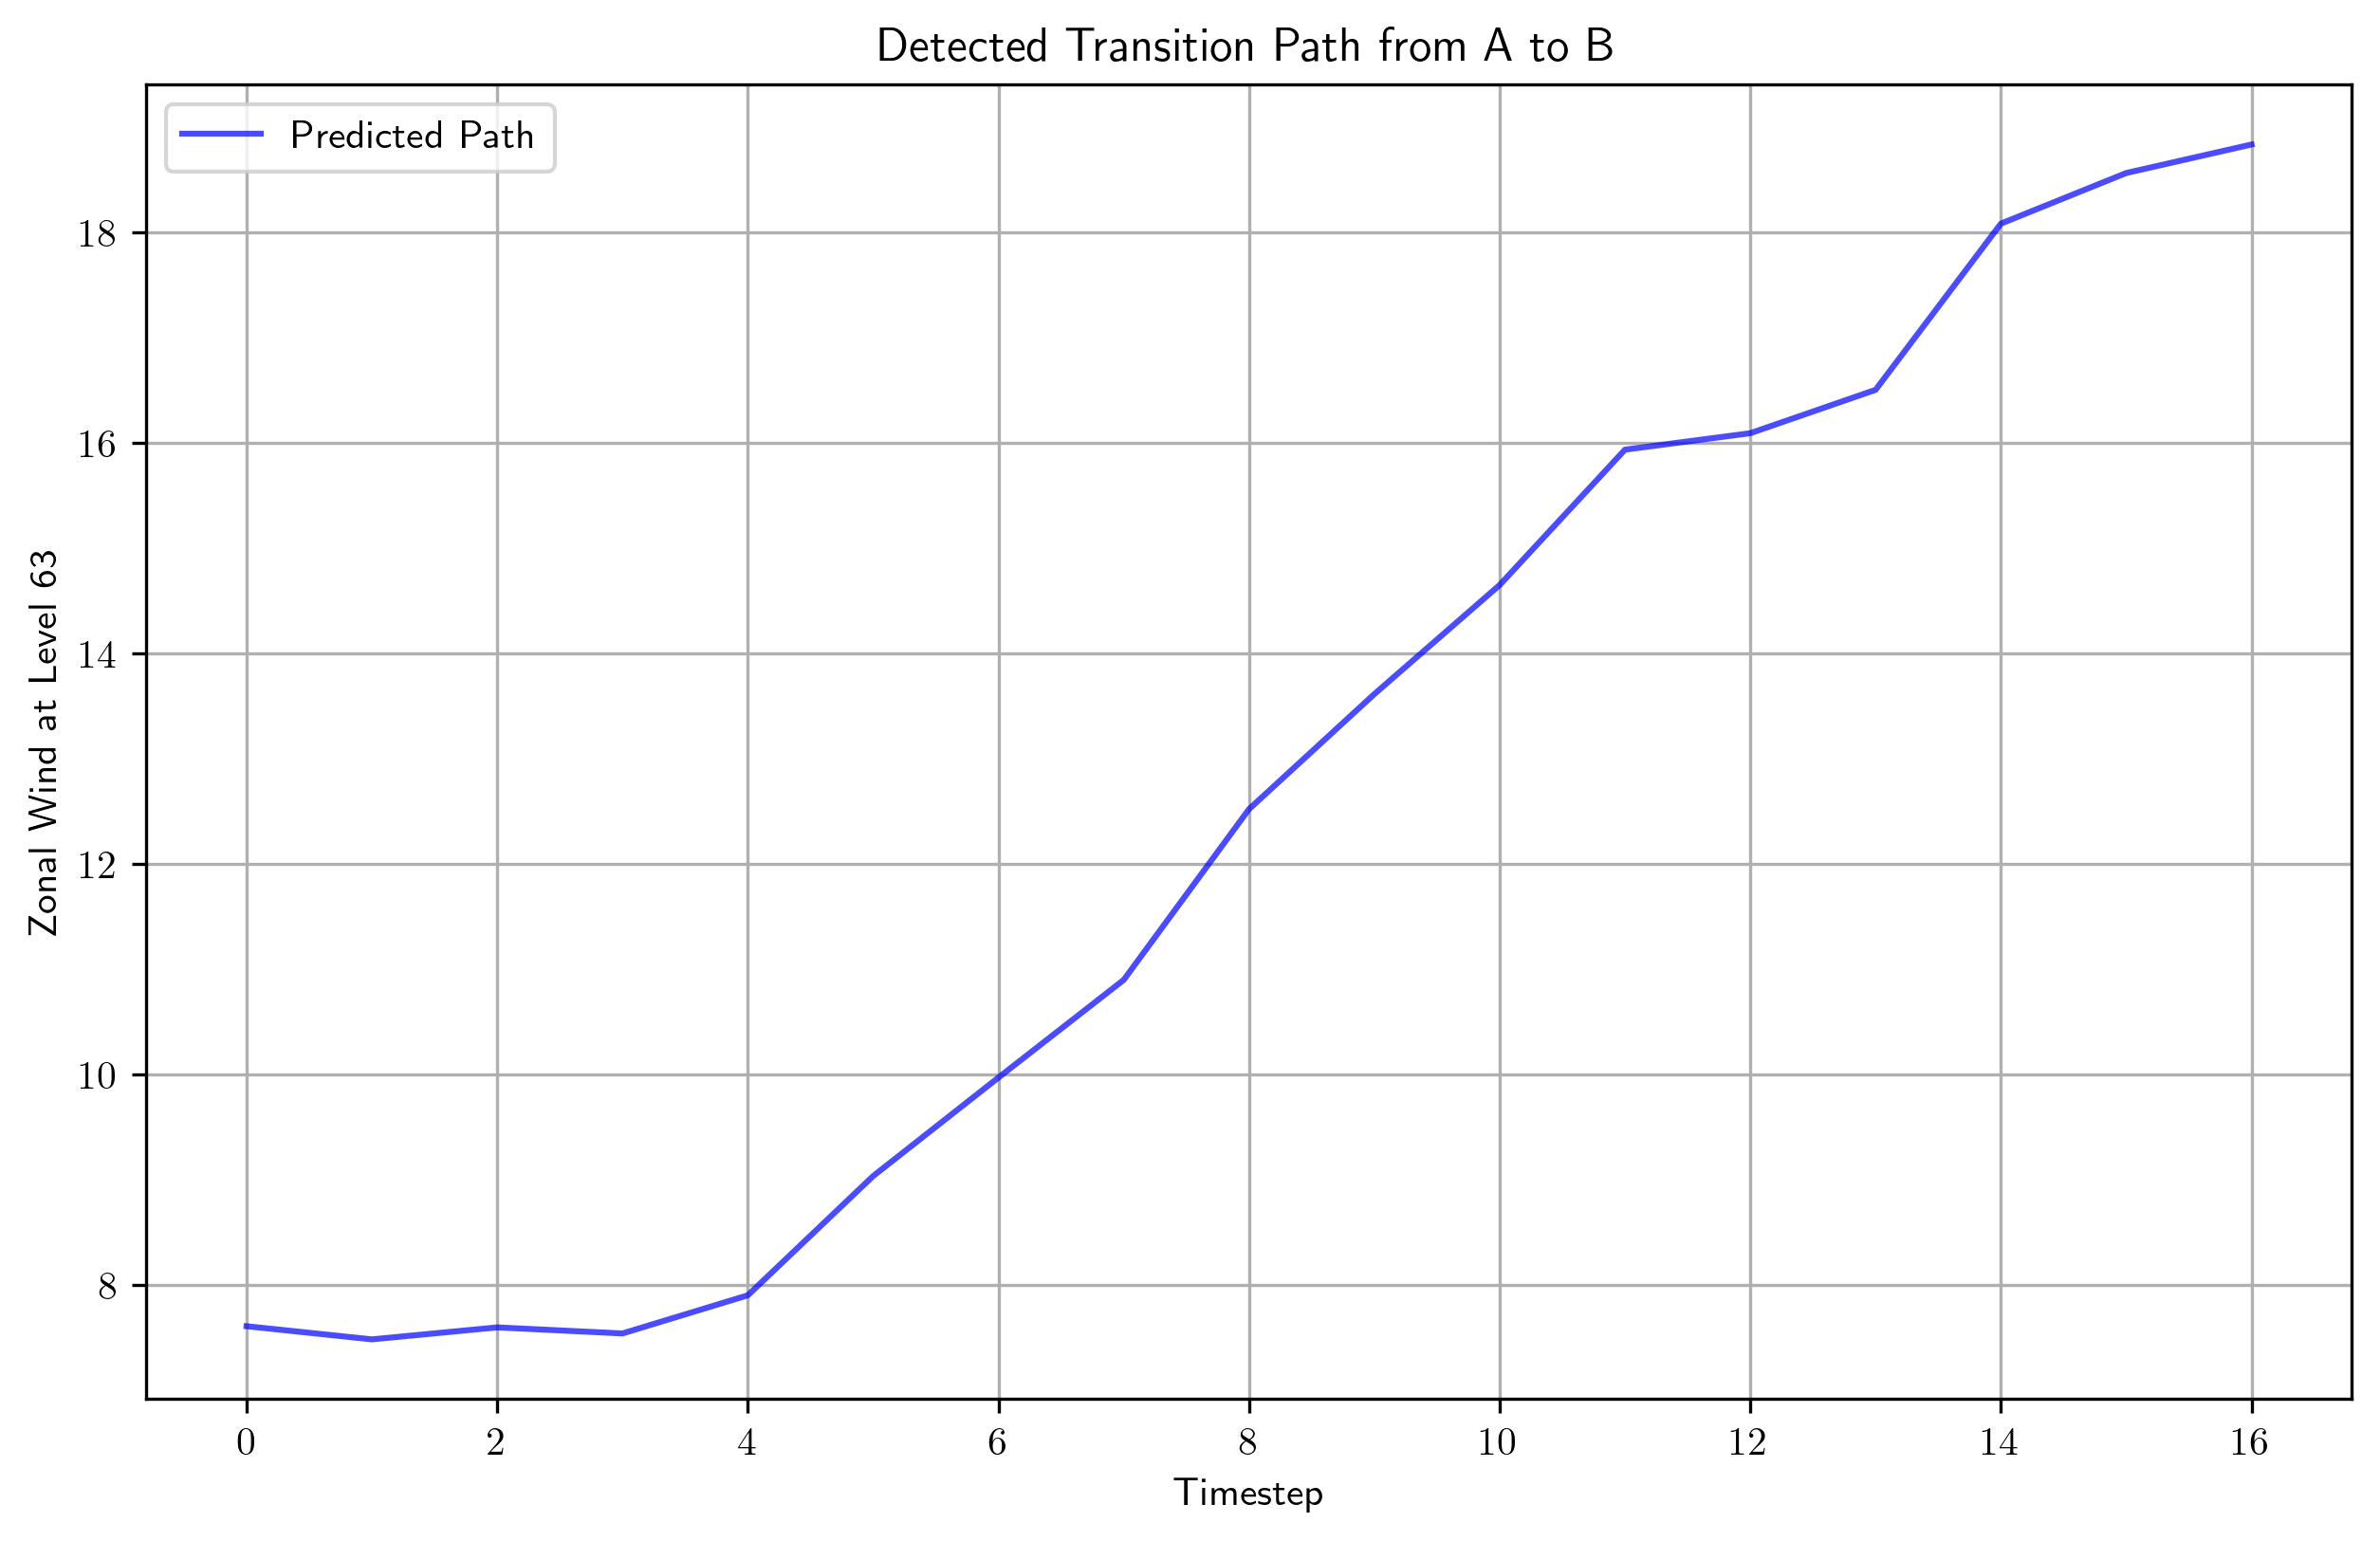

In [4]:
# Detecting A to B transitions

timesteps = 300_000
upper_bound = 18.59
lower_bound = 7.41
level = 63
A = False
B = True
T = False

save = np.load("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths/single_timestep_prediction_level_63_300_000.npy")
save = save[:, :]
actual = np.load("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
actual = actual[:timesteps,1,:]

paths = []

for i in range(timesteps):
    if save[i, level] > upper_bound:
        if T and not A:
            paths.append((d_save, i))
        A = True
        B = False
        T = False
    if save[i, level] < lower_bound:
        if T and not B:
            paths.append((d_save, i))
        B = True
        A = False
        T = False
    if lower_bound <= save[i, level] <= upper_bound and not T:
        T = True
        d_save = i  # d_save captures the START of transition

    # if save[i, level] < upper_bound and not B and not T:
    #     T = True
    #     d_save = i
    # if save[i, level] > lower_bound and not A and not T:
    #     T = True
    #     d_save = i
    # if save[i, level] > upper_bound and T and not A:
    #     A = True
    #     B = False
    #     T = False
    #     paths.append((d_save, i))
    # if save[i, level] < lower_bound and T and not B:
    #     B = True
    #     A = False
    #     T = False
    #     paths.append((d_save, i))

for path in paths[:5]:
    start_of_path, end_of_path = path
    plt.figure(figsize=(10,6))
    plt.plot(save[start_of_path:end_of_path+1, level], label='Predicted Path', color='red', alpha=0.7)
    plt.xlabel('Timestep')
    plt.ylabel('Zonal Wind at Level 63')
    plt.title('Detected Transition Path from A to B')
    plt.legend()
    plt.grid()
    plt.show()

real_paths = []
unnorm_psi = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')
unnorm_psi = unnorm_psi[:timesteps,1,:]
for i in range(timesteps):
    if unnorm_psi[i, level] > upper_bound:
        if T and not A:
            real_paths.append((d_save, i))
        A = True
        B = False
        T = False
    if unnorm_psi[i, level] < lower_bound:
        if T and not B:
            real_paths.append((d_save, i))
        B = True
        A = False
        T = False
    if lower_bound <= unnorm_psi[i, level] <= upper_bound and not T:
        T = True
        d_save = i  # d_save captures the START of transition

for path in real_paths[:5]:
    start_of_path, end_of_path = path
    plt.figure(figsize=(10,6))
    plt.plot(unnorm_psi[start_of_path:end_of_path+1, level], label='Predicted Path', color='blue', alpha=0.7)
    plt.xlabel('Timestep')
    plt.ylabel('Zonal Wind at Level 63')
    plt.title('Detected Transition Path from A to B')
    plt.legend()
    plt.grid()
    plt.show()

In [5]:
import seaborn as sns

timesteps = 1_000_000
real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")

real_data = real_data[:, 1, :]
real_data = real_data[:timesteps, :]
save = save[:timesteps, :]
zonal_wind = real_data[:, 63]

In [ ]:
# First figure: real time series + histogram overlay
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].plot(real_data[:60000, 63], label='Real', color='blue', alpha=0.7)
sns.histplot(y =zonal_wind, bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Real Data', ax=ax[0, 1])
ax[0, 0].set_xlabel('Time [Days]')
ax[0, 0].set_ylabel('U(30 km) [m/s]')
ax[0, 0].set_title('Holton-Mass Model U(30 km)')
ax[0, 0].legend()
ax[0, 0].grid()

# Second figure: predicted time series + histogram overlay
ax[1, 0].plot(save[:60000, 63], label='Predicted', color='red', alpha=0.7)
sns.histplot(y = save[:, 63], bins=50, kde=True, color='red', alpha=0.6, element='step', label='Predictions', ax=ax[1, 1])
sns.histplot(y =zonal_wind, bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Real Data', ax=ax[1, 1], fill=False)
ax[1, 0].set_xlabel('Time [Days]')
ax[1, 0].set_ylabel('U(30 km) [m/s]')
ax[1, 0].set_title('Emulator U(30 km)')
ax[1, 0].legend()
ax[1, 0].grid()
plt.tight_layout()
plt.show()

# Overlayed timeseries

plt.figure(figsize=(10,6))
plt.plot(real_data[:60000, 63], label='Model', color='blue', alpha=0.7)
plt.plot(save[:60000, 63], label='Emulator', color='red', alpha=0.7)
plt.xlabel('Timestep')
plt.ylabel('U(30)')
plt.title('U(30) Timeseries of Model vs Emulator | 60k days')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import matplotlib.gridspec as gridspec

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(real_data[:60000, 63], label='Holton-Mass', color='blue', alpha=0.7)
sns.histplot(y =zonal_wind, bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Real Data', ax=ax[1])
ax[0].set_ylim([-20, 35])
ax[0].set_xlabel('Day')
ax[0].set_ylabel('U(30)')
ax[0].set_title('Physical U(30) Time Series')
ax[0].grid()
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('U(30)')
ax[1].set_title('PDF of Physical U(30)')
ax[1].grid()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(save[:60000, 63], label='Emulator', color='red', alpha=0.7)
sns.histplot(y = save[:, 63], bins=50, kde=True, color='red', alpha=0.6, element='step', label='Emulator', ax=ax[1])
ax[0].set_ylim([-20, 35])
ax[0].set_xlabel('Day')
ax[0].set_ylabel('U(30)')
ax[0].set_title('Emulator U(30) Time Series')
ax[0].grid()
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('U(30)')
ax[1].set_title('PDF of Emulator U(30)')
ax[1].grid()
plt.tight_layout()
plt.show()

In [ ]:
from scipy import sparse as sps

def D1mat(n,dz,lower_value,lower_type,upper_value,upper_type):
    # coeff is the coefficient to multiply the derivative by
    D = np.zeros((n,n))
    C = np.zeros(n)
    D[np.arange(1,n-1),np.arange(2,n)] = 1.0/(2*dz)
    D[np.arange(1,n-1),np.arange(n-2)] = -1.0/(2*dz)
    # Lower boundary
    if lower_type == 'dirichlet':
        D[0,1] = 1.0/(2*dz)
        C[0] = -lower_value/(2*dz)
    elif lower_type == 'neumann':
        D[0,[0,1]] = 2.0/3*np.array([-1,1])/dz
        C[0] = 1.0/3*lower_value
    # Upper boundary
    if upper_type == 'dirichlet':
        D[n-1,n-2] = -1.0/(2*dz)
        C[n-1] = upper_value/(2*dz)
    elif upper_type == 'neumann':
        D[n-1,[n-2,n-1]] = 2.0/3*np.array([-1,1])/dz
        C[n-1] = 1.0/3*upper_value
    return C,D

def D2mat(n,dz,lower_value,lower_type,upper_value,upper_type):
    D = np.zeros((n,n))
    C = np.zeros(n)
    D[np.arange(1,n-1),np.arange(1,n-1)] = -2.0/dz**2
    D[np.arange(1,n-1),np.arange(n-2)] = 1.0/dz**2
    D[np.arange(1,n-1),np.arange(2,n)] = 1.0/dz**2
    # Lower boundary
    if lower_type == 'dirichlet':
        D[0,[0,1]] = np.array([-2,1])/dz**2
        C[0] = lower_value/dz**2
    elif lower_type == 'neumann':
        D[0,[0,1]] = np.array([-1,1])/(1.5*dz**2)
        C[0] = -1.0/(1.5*dz)*lower_value
    # Upper boundary
    if upper_type == 'dirichlet':
        D[n-1,[n-2,n-1]] = np.array([1,-2])/dz**2
        C[n-1] = upper_value/dz**2
    elif upper_type == 'neumann':
        D[n-1,[n-2,n-1]] = -np.array([-1,1])/(1.5*dz**2)
        C[n-1] = 1.0/(1.5*dz)*upper_value
    return C,D

def first_derivative(F,lower,upper,dz):
    # Compute the first z derivatives any field
    Nt,n = F.shape
    Fz = np.zeros([Nt,n])
    Fz[:,1:-1] = (F[:,2:n] - F[:,0:n-2]) / (2*dz)
    Fz[:,0] = (F[:,1] - lower)/(2*dz)
    Fz[:,-1] = (upper - F[:,-2])/(2*dz)
    return Fz

def second_derivative(F,lower,upper,dz):
    # Compute the first z derivatives any field
    Nt,n = F.shape
    Fzz = np.zeros([Nt,n])
    Fzz[:,1:-1] = (F[:,2:n] + F[:,0:n-2] - 2*F[:,1:-1]) / (dz**2)
    Fzz[:,0] = (F[:,1] + lower - 2*F[:,0])/(dz**2)
    Fzz[:,-1] = (upper + F[:,-2] - 2*F[:,-1])/(dz**2)
    return Fzz

tau = 0.25
kappa = 0.0
sigma = 1.0
state_dim = 2
dt_sim = 0.0001
obs_dim = 2 # Observable degrees of freedom
ref_alt = 30.0
hB_d = 38.5
physical_params = dict({
    'tau': tau,
    'kappa': kappa,
    'sigma': sigma,
    'state_dim': state_dim,
    'obs_dim': obs_dim,
    'dt_sim': dt_sim,
    'ref_alt': ref_alt,
    'hB_d': hB_d,
    'du_per_day': 1.0,
    'dt_sim': 0.005,
    })

q = {
           'rad': 6370.0e3, 'g': 9.82, 'phi0': np.pi/3, 
           'sx': 2, 'zB_d': 0.0, 'zT_d': 70.0e3, 'H': 7.0e3, 
           'Omega': 2*np.pi/(24*3600), 'Nsq_d': 4.0e-4, 'ideal_gas_constant': 8.314,
           'hB_d': physical_params['hB_d'], 'Nz': 26, 'length': 2.5e5, 'time': 24*3600.0,
           'du_per_day': physical_params['du_per_day'], 'dt_sim': physical_params['dt_sim'],
        }

n = q['Nz']+1 #Number of points including boundaries
q['state_dim'] = 3*(q['Nz']-1)
#Dimensional variables
q['f0_d'] = 2*q['Omega']*np.sin(q['phi0'])
q['k_d'] = q['sx']/(q['rad']*np.cos(q['phi0']))
q['dz_d'] = (q['zT_d']-q['zB_d'])/q['Nz']
q['z_d'] = np.linspace(q['zB_d'],q['zT_d'],q['Nz']+1)
q['Psi0_d'] = q['g']*q['hB_d']/q['f0_d']
q['fn'] = q['f0_d']**2/q['Nsq_d']
#Dimensionless variables
q['Gsq'] = 1.0/(q['length']**2/q['H']**2*q['fn'])
q['k'] = q['k_d']*q['length']
q['dz'] = q['dz_d']/q['H']
q['z'] = q['z_d']/q['H']
q['Psi0'] = q['Psi0_d']*q['time']/q['length']**2

# INTEGRATED HEAT FLUX
n = q['Nz']-1
x = save  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k']
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
ihf = np.zeros((Nt,n))
ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    ihf[:,i] = ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

path = paths[1]
start_of_path, end_of_path = path
plt.figure(figsize=(10,6))
plt.plot(ihf[start_of_path:end_of_path+1, level-50], save[start_of_path:end_of_path+1, level], label='Predicted Path', color='blue', alpha=0.7)
plt.xlabel('Heat Flux at Level 13')
plt.ylabel('Mean Zonal Wind at Level 13')
plt.title('Detected Transition Path from A to B')
plt.legend()
plt.grid()
plt.show()

print(ihf.shape)

In [ ]:
import matplotlib.gridspec as gridspec

# First figure: real time series + histogram overlay
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[2, 1], height_ratios=[1, 1])
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax00.plot(real_data[:60000, 63], label='Holton-Mass', color='blue', alpha=0.7)
sns.histplot(y =zonal_wind, bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Holton-Mass', ax=ax01, stat='density')
ax00.set_ylim([-20, 35])
ax00.set_xlabel(r'Time [Days]', fontsize = 14)
ax00.set_ylabel(r'$U(30km)$ $[m/s]$', fontsize = 14)
ax00.set_title(r'Holton-Mass Model Data: $U(30km)$', fontsize = 14)
ax00.legend(loc = 'lower left')
ax00.grid()
ax01.set_xlim([0, 0.15])
ax01.set_xlabel(r'Density', fontsize = 14)
ax01.set_ylabel(r'$U(30km)$ $[m/s]$', fontsize = 14)
ax01.set_title(r'$U(30km)$ PDF', fontsize = 14)
ax01.legend(loc = 'lower left')
ax01.grid()


# Second figure: predicted time series + histogram overlay
ax10.plot(save[:60000, 63], label='Emulator', color='red', alpha=0.7)
sns.histplot(y = save[:, 63], bins=50, kde=True, color='red', alpha=0.6, element='step', label='Emulator', ax=ax11, stat='density')
sns.histplot(y =zonal_wind, bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Holton-Mass KDE', ax=ax11, fill=False, stat='density')
ax10.set_ylim([-20, 35])
ax10.set_xlabel(r'Time [Days]', fontsize = 14)
ax10.set_ylabel(r'$U(30km)$ $[m/s]$', fontsize = 14)
ax10.set_title(r'Emulator Data: $U(30km)$', fontsize = 14)
ax10.legend(loc = 'lower left')
ax10.grid()
ax11.set_xlim([0, 0.15])
ax11.set_xlabel(r'Density', fontsize = 14)
ax11.set_ylabel(r'$U(30km)$ $[m/s]$', fontsize = 14)
ax11.set_title(r'$U(30km)$ PDF', fontsize = 14)
ax11.legend(loc= 'lower left')
ax11.grid()
plt.tight_layout()
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/timeseries_U_30.png")
plt.show()

In [ ]:
print(q['length']/q['time'])

In [ ]:
# Calculating the range of mean zonal wind, streamfunction and heat flux
max_u = np.max(save[:, level])
min_u = np.min(save[:, level])
range_u = max_u - min_u

streamfunction = save[:, level-50]**2 + save[:, 2*(level-50)]**2
max_psi = np.max(streamfunction)
min_psi = np.min(streamfunction)
range_psi = max_psi - min_psi

max_ihf = np.max(ihf[:, level-50])
min_ihf = np.min(ihf[:, level-50])
range_ihf = max_ihf - min_ihf

print(f"Zonal Wind at Level {level-50}: Max = {max_u:.2f}, Min = {min_u:.2f}, Range = {range_u:.2f}")
print(f"Streamfunction at Level {level-50}: Max = {max_psi:.2f}, Min = {min_psi:.2f}, Range = {range_psi:.2f}")
print(f"IHF at Level {level-50}: Max = {max_ihf:.2f}, Min = {min_ihf:.2f}, Range = {range_ihf:.2f}")

In [ ]:
bin_size_u = range_u / 10
bin_size_psi = range_psi / 10
bin_size_ihf = range_ihf / 10

# Committor for A to B transitions and its density for mean zonal wind, streamfunction and heat flux. This includes both states A and B in the probabilities

comm_matrix = np.zeros((10, 10))

for i in range(1, len(paths), 2):  # Step by 2 to get only A to B transitions
    path = paths[i]
    start_of_path, end_of_path = path
    for i in range(start_of_path, end_of_path + 1):
        u_val = save[i, level]
        psi_val = streamfunction[i]
        ihf_val = ihf[i, level-50]

        u_bin = int((u_val - min_u) / bin_size_u)
        psi_bin = int((psi_val - min_psi) / bin_size_psi)
        ihf_bin = int((ihf_val - min_ihf) / bin_size_ihf)
        
        u_bin = min(max(u_bin, 0), 9)
        psi_bin = min(max(psi_bin, 0), 9)
        ihf_bin = min(max(ihf_bin, 0), 9)

        comm_matrix[u_bin, psi_bin] += 1
        comm_matrix[u_bin, ihf_bin] += 1
        comm_matrix[psi_bin, ihf_bin] += 1
for i in range(10):
    min_val = min_u + i * bin_size_u
    max_val = min_u + (i + 1) * bin_size_u

    if max_val > upper_bound and min_val > upper_bound:
        comm_matrix[i, :] = 0
        comm_matrix[:, i] = 0

    if max_val < lower_bound and min_val < lower_bound:
        comm_matrix[i, :] = 1
        comm_matrix[:, i] = 1

# Normalize the committor matrix to get probabilities
comm_matrix /= np.sum(comm_matrix)

# Calculating the range of mean zonal wind, streamfunction and heat flux
real_max_u = np.max(unnorm_psi[:, level])
real_min_u = np.min(unnorm_psi[:, level])
real_range_u = real_max_u - real_min_u

real_streamfunction = unnorm_psi[:, level-50]**2 + unnorm_psi[:, 2*(level-50)]**2
real_max_psi = np.max(real_streamfunction)
real_min_psi = np.min(real_streamfunction)
real_range_psi = real_max_psi - real_min_psi

n = q['Nz']-1
x = unnorm_psi  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
real_ihf = np.zeros((Nt,n))
real_ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    real_ihf[:,i] = real_ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

print(real_ihf.shape, real_ihf[0, 13])
real_max_ihf = np.max(real_ihf[:, level-50])
real_min_ihf = np.min(real_ihf[:, level-50])
real_range_ihf = real_max_ihf - real_min_ihf

# Density

In [ ]:
timesteps = 1_000_000
real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")

real_data = real_data[:, 1, :]
real_data = real_data[:timesteps, :]
save = save[:timesteps, :]
zonal_wind = real_data[:, 63]

n = q['Nz']-1
x = real_data  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k']
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
real_ihf = np.zeros((Nt,n))
real_ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    real_ihf[:,i] = real_ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

n = q['Nz']-1
x = save  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k']
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
ihf = np.zeros((Nt,n))
ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    ihf[:,i] = ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

In [ ]:
# Density Contour Plot Data for Model and Emulator 
zlevel = lambda z: np.argmin(np.abs(q['z_d'][1:-1]/1000-z))

real_ihf_13 = real_ihf[:timesteps, zlevel(30)]
density_u_ihf, u_ihf30_edges, ihf_u30_edges = np.histogram2d(zonal_wind, real_ihf_13, bins=100, density=True)
density_log_u_ihf = np.log10(density_u_ihf + 1e-5)
    
model_density_u_ihf, model_u_ihf30_edges, model_ihf_u30_edges = np.histogram2d(save[:timesteps, level], ihf[:timesteps, zlevel(30)], bins=100, density=True)
model_density_log_u_ihf = np.log10(model_density_u_ihf + 1e-5)

vmin_common = np.floor(min(np.min(density_log_u_ihf), np.min(model_density_log_u_ihf)))
vmax_common = np.ceil(max(np.max(density_log_u_ihf), np.max(model_density_log_u_ihf)))

# Apply threshold to make negligible values NaN
threshold = -5
density_log_u_ihf_masked = np.where(density_log_u_ihf > threshold, density_log_u_ihf, np.nan)
model_density_log_u_ihf_masked = np.where(model_density_log_u_ihf > threshold, model_density_log_u_ihf, np.nan)

# Create custom colormap that shows NaN as white
cmap = plt.cm.Spectral
cmap.set_bad(color='white', alpha=1.0)

# Model Data Density Contour Plot
rU30, rIHF30 = np.meshgrid(u_ihf30_edges[:-1], ihf_u30_edges[:-1], indexing='ij')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

custom_levels = np.linspace(vmin_common, vmax_common, 11)
im1 = ax[0].contourf(rIHF30.T * q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25, 
                     rU30.T * q['length']/q['time'], density_log_u_ihf_masked.T, 
                levels=custom_levels, vmin = vmin_common, vmax = vmax_common, cmap='RdBu_r', extend='both')

ax[0].set_xlabel(r"$IHF(30 km)$ $[K\cdot m^2 / s]$", fontsize = 20)
ax[0].set_ylabel(r'$U(30 km)$ $[m/s]$', fontsize = 20)
ax[0].set_title(r'Holton-Mass Model Data: Steady State Density $\pi(x)$', fontweight='bold', fontsize = 20)
ax[0].set_facecolor('white')
ax[0].set_ylim(-60,90)
ax[0].set_xlim(-25000,80000)

plt.colorbar(im1, ax=ax[0], label='log10(Count + 1e-10)')

# Emulator Data Density Contour Plot
mU30, mIHF30 = np.meshgrid(model_u_ihf30_edges[:-1], model_ihf_u30_edges[:-1], indexing='ij')

custom_levels_emulator = np.linspace(vmin_common, vmax_common, 11)
im2 = ax[1].contourf(mIHF30.T * q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25, 
                     mU30.T * q['length']/q['time'], model_density_log_u_ihf_masked.T, 
                levels=custom_levels_emulator, vmin = vmin_common, vmax = vmax_common, cmap = 'RdBu_r', extend='both')

ax[1].set_xlabel(r"$IHF(30 km)$ $[K\cdot m^2 / s]$", fontsize = 20)
ax[1].set_ylabel(r'$U(30 km)$ $[m/s]$', fontsize = 20)
ax[1].set_title(r'Emulator Data: Steady State Density $\pi(x)$', fontweight='bold', fontsize = 20)
ax[1].set_facecolor('white')
ax[1].set_ylim(-60,90)
ax[1].set_xlim(-25000,80000)

plt.colorbar(im2, ax=ax[1], label='log10(Count + 1e-10)')
plt.tight_layout(pad=1.0)
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/steady_state.png")
plt.show()

In [ ]:
cmap = plt.cm.Spectral
cmap.set_bad(color='white', alpha=1.0)

# Model Data Density Contour Plot
rU30, rIHF30 = np.meshgrid(u_ihf30_edges[:-1], ihf_u30_edges[:-1], indexing='ij')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

custom_levels = np.linspace(vmin_common, vmax_common, 11)
im1 = ax[0].contourf(rIHF30.T * q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25, 
                     rU30.T * q['length']/q['time'], density_log_u_ihf_masked.T, 
                levels=custom_levels, vmin = vmin_common, vmax = vmax_common, cmap='RdBu_r', extend='both')

ax[0].set_xlabel(r"$IHF(30 km)$ $[K\cdot m^2 / s]$", fontsize=20)
ax[0].set_ylabel(r'$U(30 km)$ $[m/s]$', fontsize=20)
ax[0].set_title(r'Holton-Mass Model Data: Steady State Density $\pi(x)$', fontweight='bold', fontsize=20)
ax[0].set_facecolor('white')
ax[0].set_ylim(-60,90)
ax[0].set_xlim(-25000,80000)

cbar1 = plt.colorbar(im1, ax=ax[0])
cbar1.set_label('log10(Count + 1e-10)', fontsize=14)

# Emulator Data Density Contour Plot
mU30, mIHF30 = np.meshgrid(model_u_ihf30_edges[:-1], model_ihf_u30_edges[:-1], indexing='ij')

custom_levels_emulator = np.linspace(vmin_common, vmax_common, 11)
im2 = ax[1].contourf(mIHF30.T * q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25, 
                     mU30.T * q['length']/q['time'], model_density_log_u_ihf_masked.T, 
                levels=custom_levels_emulator, vmin = vmin_common, vmax = vmax_common, cmap = 'RdBu_r', extend='both')

ax[1].set_xlabel(r"$IHF(30 km)$ $[K\cdot m^2 / s]$", fontsize=20)
ax[1].set_ylabel(r'$U(30 km)$ $[m/s]$', fontsize=20)
ax[1].set_title(r'Emulator Data: Steady State Density $\pi(x)$', fontweight='bold', fontsize=20)
ax[1].set_facecolor('white')
ax[1].set_ylim(-60,90)
ax[1].set_xlim(-25000,80000)

cbar2 = plt.colorbar(im2, ax=ax[1])
cbar2.set_label('log10(Count + 1e-10)', fontsize=14)

plt.tight_layout(pad=1.0)
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/steady_state.png")
plt.show()

# PDF

In [ ]:
def detect_transitions_A_to_B(u_series, upper, lower):
    transitions = []
    transitions_length = []
    i = 0
    while i < len(u_series) - 1:
        if u_series[i-1] > upper and u_series[i] <= upper:
            j = i + 1
            while j < len(u_series) and u_series[j] <= upper:
                if u_series[j] < lower:
                    transitions.append(i)
                    transitions_length.append((i, j))
                    break
                j += 1
            i = j
        else:
            i += 1
    return np.array(transitions), np.array(transitions_length)

def detect_transitions_B_to_A(u_series, upper, lower):
    transitions = []
    transitions_length = []
    i = 0
    while i < len(u_series) - 1:
        if u_series[i-1] < lower and u_series[i] >= lower:
            j = i + 1
            while j < len(u_series) and u_series[j] >= lower:
                if u_series[j] > upper:
                    transitions.append(i)
                    transitions_length.append((i, j))
                    break
                j += 1
            i = j
        else:
            i += 1
    return np.array(transitions), np.array(transitions_length)

plt.figure(figsize=(10,6))

real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths/single_timestep_prediction_level_63_300_000.npy")

_, model_lengths_AB = detect_transitions_A_to_B(real_data[:timesteps, 1, level], upper_bound, lower_bound)
_, model_lengths_BA = detect_transitions_B_to_A(real_data[:timesteps, 1, level], upper_bound, lower_bound)
_, emulator_lengths_AB = detect_transitions_A_to_B(save[:timesteps, level], upper_bound, lower_bound)
_, emulator_lengths_BA = detect_transitions_B_to_A(save[:timesteps, level], upper_bound, lower_bound)

# Model CDF of transitions times

model_lengths_v_AB = []
for length in model_lengths_AB:
    model_lengths_v_AB.append(length[1] - length[0] + 1)
model_lengths_AB = np.array(model_lengths_v_AB)

emulator_lengths_v_AB = []
for length in emulator_lengths_AB:
    emulator_lengths_v_AB.append(length[1] - length[0] + 1)
emulator_lengths_AB = np.array(emulator_lengths_v_AB)

model_lengths_v_BA = []
for length in model_lengths_BA:
    model_lengths_v_BA.append(length[1] - length[0] + 1)
model_lengths_BA = np.array(model_lengths_v_BA)

emulator_lengths_v_BA = []
for length in emulator_lengths_BA:
    emulator_lengths_v_BA.append(length[1] - length[0] + 1)
emulator_lengths_BA = np.array(emulator_lengths_v_BA)

min_tr_AB = min(len(model_lengths_AB), len(emulator_lengths_AB))
model_lengths_AB = model_lengths_AB[:min_tr_AB]
emulator_lengths_AB = emulator_lengths_AB[:min_tr_AB]

min_tr_BA = min(len(model_lengths_BA), len(emulator_lengths_BA))
model_lengths_BA = model_lengths_BA[:min_tr_BA]
emulator_lengths_BA = emulator_lengths_BA[:min_tr_BA]

model_lengths = np.concatenate((model_lengths_AB, model_lengths_BA), axis=0)
emulator_lengths = np.concatenate((emulator_lengths_AB, emulator_lengths_BA), axis=0)

print(model_lengths.shape, emulator_lengths.shape)
plt.ecdf(model_lengths, label='Model', color = 'blue')
plt.ecdf(emulator_lengths, label='Emulator', color = 'red')

plt.title(r'Model \& Emulator CDF of Transition Times')
plt.xlabel('Transition Time in Days')
plt.ylabel('CDF')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths/single_timestep_prediction_level_63_300_000.npy")

_, model_lengths_AB = detect_transitions_A_to_B(real_data[:timesteps, 1, level], upper_bound, lower_bound)
_, emulator_lengths_AB = detect_transitions_A_to_B(save[:timesteps, level], upper_bound, lower_bound)

# Model CDF of transitions times

model_lengths_v_AB = []
for length in model_lengths_AB:
    model_lengths_v_AB.append(length[1] - length[0] + 1)
model_lengths_AB = np.array(model_lengths_v_AB)

emulator_lengths_v_AB = []
for length in emulator_lengths_AB:
    emulator_lengths_v_AB.append(length[1] - length[0] + 1)
emulator_lengths_AB = np.array(emulator_lengths_v_AB)

min_tr_AB = min(len(model_lengths_AB), len(emulator_lengths_AB))
model_lengths_AB = model_lengths_AB[:min_tr_AB]
emulator_lengths_AB = emulator_lengths_AB[:min_tr_AB]

print(model_lengths_AB.shape, emulator_lengths_AB.shape)
plt.ecdf(model_lengths_AB, label='Model', color = 'blue')
plt.ecdf(emulator_lengths_AB, label='Emulator', color = 'red')

plt.title(r'Model \& Emulator CDF of AB Transition Times')
plt.xlabel('Transition Time in Days')
plt.ylabel('CDF')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths/single_timestep_prediction_level_63_300_000.npy")

_, model_lengths_BA = detect_transitions_B_to_A(real_data[:timesteps, 1, level], upper_bound, lower_bound)
_, emulator_lengths_BA = detect_transitions_B_to_A(save[:timesteps, level], upper_bound, lower_bound)

# Model CDF of transitions times

model_lengths_v_BA = []
for length in model_lengths_BA:
    model_lengths_v_BA.append(length[1] - length[0] + 1)
model_lengths_BA = np.array(model_lengths_v_BA)

emulator_lengths_v_BA = []
for length in emulator_lengths_BA:
    emulator_lengths_v_BA.append(length[1] - length[0] + 1)
emulator_lengths_BA = np.array(emulator_lengths_v_BA)

min_tr_BA = min(len(model_lengths_BA), len(emulator_lengths_BA))
model_lengths_BA = model_lengths_BA[:min_tr_BA]
emulator_lengths_BA = emulator_lengths_BA[:min_tr_BA]

print(model_lengths_BA.shape, emulator_lengths_BA.shape)
plt.ecdf(model_lengths_BA, label='Model', color = 'blue')
plt.ecdf(emulator_lengths_BA, label='Emulator', color = 'red')

plt.title(r'Model \& Emulator CDF of BA Transition Times')
plt.xlabel('Transition Time in Days')
plt.ylabel('CDF')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(zonal_wind[:500], label='Physical', color='blue', alpha=0.7)
plt.plot(save[:500, 63], label='Emulator', color='red', alpha=0.7)
plt.xlabel('Day')
plt.ylabel('U(30)')
plt.title('U(30) Physical vs Emulator Data')
plt.legend()
plt.grid()
plt.show()

# Committor

In [ ]:
def create_committor_matrix(data_u, data_ihf, transition_indices, state_A_indices, state_B_indices, 
                          u_bounds, ihf_bounds, n_bins=200):
    """
    Create a committor matrix that tracks probability of A to B transition.
    
    Args:
        data_u: Zonal wind values
        data_ihf: IHF values  
        transition_indices: Indices of points in transition region
        state_A_indices: Indices of points in state A
        state_B_indices: Indices of points in state B
        u_bounds: bounds for zonal wind
        ihf_bounds: bounds for IHF
        n_bins: Number of bins 
    
    Returns:
        committor_matrix: Matrix with transition probabilities
        u_edges, ihf_edges: Bin edges for plotting
    """
    
    # Initialize matrices
    transition_counts = np.zeros((n_bins, n_bins))  # Count of transitions to B
    total_counts = np.zeros((n_bins, n_bins))       # Total count of visits
    committor_matrix = np.full((n_bins, n_bins), np.nan)
    
    # Create bins
    u_edges = np.linspace(u_bounds[0], u_bounds[1], n_bins + 1)
    ihf_edges = np.linspace(ihf_bounds[0], ihf_bounds[1], n_bins + 1)
    u_bin_size = (u_bounds[1] - u_bounds[0]) / n_bins
    ihf_bin_size = (ihf_bounds[1] - ihf_bounds[0]) / n_bins
    
    # Process all data points to count visits
    for i in range(len(data_u)):
        u_val = data_u[i]
        ihf_val = data_ihf[i]
        
        # Find bin indices
        u_bin = int((u_val - u_bounds[0]) / u_bin_size)
        ihf_bin = int((ihf_val - ihf_bounds[0]) / ihf_bin_size)
        
        # Ensure bins are within bounds
        u_bin = min(max(u_bin, 0), n_bins - 1)
        ihf_bin = min(max(ihf_bin, 0), n_bins - 1)
        
        # Count total visits
        total_counts[u_bin, ihf_bin] += 1
        
        # If this point is in transition region, check if it leads to state B
        if (i in transition_indices):
            # Look ahead to see if this transition leads to state B
            # Find the next state this point transitions to
            future_window = min(1000, len(data_u) - i - 1)  # Look ahead up to 1000 steps
            
            for j in range(1, future_window + 1):
                future_idx = i + j
                if future_idx in state_B_indices:
                    transition_counts[u_bin, ihf_bin] += 1
                    break
                elif future_idx in state_A_indices:
                    # Went back to A, don't count as transition to B
                    break
    
    # Calculate probabilities only where we have data
    mask = total_counts > 0
    committor_matrix[mask] = transition_counts[mask] / total_counts[mask]
    print(committor_matrix[mask], transition_counts[mask], total_counts[mask])
    # Set boundary conditions only for bins with data
    for i in range(n_bins):
        for j in range(n_bins):
            if total_counts[i, j] > 0:  # Only set if we have data in this bin
                u_center = u_bounds[0] + (i + 0.5) * u_bin_size
                
                # State A: probability = 0
                if u_center > upper_bound:
                    committor_matrix[i, j] = 0.0
                
                # State B: probability = 1  
                elif u_center < lower_bound:
                    committor_matrix[i, j] = 1.0
    
    return committor_matrix, u_edges, ihf_edges


In [ ]:
from matplotlib import axes

timesteps = 1_000_000
real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")

real_data = real_data[:, 1, :]
real_data = real_data[:timesteps, :]
save = save[:timesteps, :]

n = q['Nz']-1
x = real_data  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
real_ihf = np.zeros((Nt,n))
real_ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    real_ihf[:,i] = real_ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

n = q['Nz']-1
x = save  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
ihf = np.zeros((Nt,n))
ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    ihf[:,i] = ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']


# Real U(30)
rmin1   = np.min(real_data[:, level])
rmax1   = np.max(real_data[:, level])
rud     = real_data[:, level]

# Real IHF(30)
rmin3   = np.min(real_ihf[:, level-50])
rmax3   = np.max(real_ihf[:, level-50])
ruhf     = real_ihf[:, level-50]

# Model U(30)
min1   = np.min(save[:, level])
max1   = np.max(save[:, level])
mud     = save[:, level]

# Model IHF(30)
min3   = np.min(ihf[:, level-50])
max3   = np.max(ihf[:, level-50])
muhf     = ihf[:, level-50]

# Real Transition region indices
cd = (real_data[:, level] <= upper_bound) & (real_data[:, level] >= lower_bound)
rT_idxs = np.where(cd)[0]

# Real State A and B indices
cd_A = (real_data[:, level] > upper_bound)
cd_B = (real_data[:, level] < lower_bound)
rA_idxs = np.where(cd_A)[0]
rB_idxs = np.where(cd_B)[0]

# Model Transition region indices
mcd = (save[:, level] <= upper_bound) & (save[:, level] >= lower_bound)
mT_idxs = np.where(mcd)[0]

# Model State A and B indices
mcd_A = (save[:, level] > upper_bound)
mcd_B = (save[:, level] < lower_bound)
mA_idxs = np.where(mcd_A)[0]
mB_idxs = np.where(mcd_B)[0]

# Committor plot function

def committor_plot(rmin1, rmax1, rmin2, rmax2, r1d, r2d, min1, max1, min2, max2, 
                   m1d, m2d, n, l, rT_idxs, rA_idxs, rB_idxs, mT_idxs, mA_idxs, mB_idxs, up, lw, n_bins):

    print("Creating committor matrix for real data...")
    # Create committor matrix for real data
    rcomm, r1_edges, r2_edges = create_committor_matrix(
        r1d, r2d, rT_idxs, rA_idxs, rB_idxs,[rmin1, rmax1], [rmin2, rmax2], n_bins)

    print("Creating committor matrix for model data...")
    # Create committor matrix for model data
    mcomm, m1_edges, m2_edges = create_committor_matrix(
        m1d, m2d, mT_idxs, mA_idxs, mB_idxs, [min1, max1], [min2, max2], n_bins)

    # Real data committor
    r1, r2 = np.meshgrid(r1_edges[:-1], r2_edges[:-1], indexing='ij')
    # Mask NaN values for white background
    rcomm_masked = np.ma.masked_invalid(rcomm)

    # Model data committor
    m1, m2 = np.meshgrid(m1_edges[:-1], m2_edges[:-1], indexing='ij')
    # Mask NaN values for white background
    mcomm_masked = np.ma.masked_invalid(mcomm)

    return rcomm, rcomm_masked, r1, r2, mcomm, mcomm_masked, m1, m2, axes

rcomm, rcomm_masked, r1, r2, mcomm, mcomm_masked, m1, m2, axes = committor_plot(rmin1, rmax1, rmin3, rmax3, 
                                                                                rud, ruhf, min1, max1, min3, max3,
                                                                                mud, muhf, n, level, rT_idxs, rA_idxs, 
                                                                                rB_idxs, mT_idxs, mA_idxs, mB_idxs, 
                                                                                upper_bound, lower_bound, n_bins=90)

In [ ]:
# Plotting with white background for no data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create custom colormap with white for NaN values
from matplotlib.colors import ListedColormap
from matplotlib.cm import RdBu_r
import matplotlib.colors as mcolors

# Get the RdBu_r colormap
cmap = plt.cm.RdBu_r
# Set the color for bad/missing values to white
cmap.set_bad(color='white')

im1 = axes[0].contourf(r2.T * q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25, 
                           r1.T * q['length']/q['time'], rcomm_masked.T, 
                        levels=20, cmap=cmap, vmin=0, vmax=1, extend='neither')

contour_50 = axes[0].contour(r2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                                r1.T * (q['length']/q['time']), rcomm_masked.T, 
                                levels=[0.5], colors='black', linewidths=2)
axes[0].clabel(contour_50, fmt={0.5: '50%'}, inline=True, fontsize=10)

axes[0].set_xlabel(r"$IHF(30km)$ $[K \cdot m^2/s]$", fontsize=20)
axes[0].set_ylabel(r'$U(30km)$ $[m/s]$', fontsize=20)
axes[0].set_title(r'Holton-Mass Model Data: Committor $q^+(x)$', fontsize=20)
axes[0].set_xlim(-20000, 80000)
axes[0].set_ylim(-60, 90)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label(r'$q^+(x)$', fontsize=16)

# Add boundary lines
axes[0].axhline(y=upper_bound * (q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[0].axhline(y=lower_bound * (q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[0].legend()

im2 = axes[1].contourf(m2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                        m1.T * (q['length']/q['time']), mcomm_masked.T, 
                    levels=20, cmap=cmap, vmin=0, vmax=1, extend='neither')

contour_50_model = axes[1].contour(m2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                                    m1.T * (q['length']/q['time']), mcomm_masked.T, 
                        levels=[0.5], colors='black', linewidths=2)
axes[1].clabel(contour_50_model, fmt={0.5: '50%'}, inline=True, fontsize=10)

axes[1].set_xlabel(r"$IHF(30km)$ $[K \cdot m^2/s]$", fontsize=20)
axes[1].set_ylabel(r'$U(30km)$ $[m/s]$', fontsize=20)
axes[1].set_title(r'Emulator Data: Committor $q^+(x)$', fontsize=20)
axes[1].set_xlim(-20000, 80000)
axes[1].set_ylim(-60, 90)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('white')

cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label(r'$q^+(x)$', fontsize=16)

# Add boundary lines
axes[1].axhline(y=upper_bound * (q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[1].axhline(y=lower_bound * (q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[1].legend()

plt.tight_layout()
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/committor.png")
plt.show()

# Print statistics
print(f"\nReal Data Statistics:")
print(f"Points in state A: {len(rA_idxs)}")
print(f"Points in state B: {len(rB_idxs)}")
print(f"Points in transition region: {len(rT_idxs)}")
print(f"Valid committor values: {np.sum(~np.isnan(rcomm))}/{rcomm.size}")

print(f"\nModel Data Statistics:")
print(f"Points in state A: {len(mA_idxs)}")
print(f"Points in state B: {len(mB_idxs)}")
print(f"Points in transition region: {len(mT_idxs)}")
print(f"Valid committor values: {np.sum(~np.isnan(mcomm))}/{mcomm.size}")

# Calculate average transition probabilities in transition region
real_transition_probs = rcomm[~np.isnan(rcomm)]
model_transition_probs = mcomm[~np.isnan(mcomm)]

print(f"\nTransition Region Analysis:")
print(f"Real data - Mean transition probability: {np.mean(real_transition_probs):.3f}")
print(f"Model data - Mean transition probability: {np.mean(model_transition_probs):.3f}")

# Lead Time

In [ ]:
timesteps = 1_000_000
real_data = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
save = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")

real_data = real_data[:, 1, :]
real_data = real_data[:timesteps, :]
save = save[:timesteps, :]

def lead_time_matrix(d1, d2, T_idxs, A_idxs, B_idxs, 
                     bs1, bs2, n_bins):
    """
    Create a lead time matrix that tracks average lead times from A to B.
    
    Args:
        d1: Zonal wind values
        d2: IHF values  
        T_idxs: Indices of points in transition region
        A_idxs: Indices of points in state A
        B_idxs: Indices of points in state B
        bs1: bounds for zonal wind
        bs2: bounds for IHF
        n_bins: Number of bins
    
    Returns:
        lead_time_matrix: Matrix with average lead times
        edg1, edg2: Bin edges for plotting"""
    
    # Initialize matrices
    lead_times_sum = np.zeros((n_bins, n_bins))  # Sum of lead times
    lead_times_count = np.zeros((n_bins, n_bins))  # Count of transitions
    lead_time_matrix = np.full((n_bins, n_bins), np.nan)
    
    # Create bins
    edg1 = np.linspace(lower_bound, upper_bound, n_bins + 1)
    edg2 = np.linspace(bs2[0], bs2[1], n_bins + 1)
    bsize1 = (upper_bound - lower_bound) / n_bins
    bsize2 = (bs2[1] - bs2[0]) / n_bins
    
    # Process all data points to count das
    for i in range(len(d1)):
        if i in T_idxs:
            u_val = d1[i]
            ihf_val = d2[i]
            
            # Find bin indices
            u_bin = int((u_val - lower_bound) / bsize1)
            ihf_bin = int((ihf_val - bs2[0]) / bsize2)
            
            # Ensure bins are within bounds
            u_bin = min(max(u_bin, 0), n_bins - 1)
            ihf_bin = min(max(ihf_bin, 0), n_bins - 1)
            
            # Count total visits
            future_window = min(1000, len(d1) - i - 1)  # Look ahead up to 1000 steps
            
            for j in range(1, future_window + 1):
                future_idx = i + j
                if future_idx in B_idxs:
                    lead_times_sum[u_bin, ihf_bin] += j
                    lead_times_count[u_bin, ihf_bin] += 1
                    break
                elif future_idx in A_idxs:
                    # Went back to A, don't count as transition to B
                    break

    mask = lead_times_count > 0
    lead_time_matrix[mask] = lead_times_sum[mask] / lead_times_count[mask]

    return lead_time_matrix, edg1, edg2

n = q['Nz']-1
x = real_data  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
real_ihf = np.zeros((Nt,n))
real_ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    real_ihf[:,i] = real_ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']

n = q['Nz']-1
x = save  # Use the 'save' array as 'x'
Nt = len(x)
heat_flux = np.ones([Nt,n+1])
heat_flux *= q['k'] #q['k_d']*q['H']*q['f0_d']/(2*q['ideal_gas_constant'])
#heat_flux *= np.exp(q['z'][:-1])*17.0/35
# Now it has to be multiplied by vertical derivatives
Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
heat_flux[:,0] *= q['Psi0']*Yz0
heat_flux *= np.exp(-q['z'][:-1])
ihf = np.zeros((Nt,n))
ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
for i in range(1,n):
    ihf[:,i] = ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']


# Real U(30)
rmin1   = np.min(real_data[:, level])
rmax1   = np.max(real_data[:, level])
rud     = real_data[:, level]

# Real IHF(30)
rmin3   = np.min(real_ihf[:, level-50])
rmax3   = np.max(real_ihf[:, level-50])
ruhf     = real_ihf[:, level-50]

# Model U(30)
min1   = np.min(save[:, level])
max1   = np.max(save[:, level])
mud     = save[:, level]

# Model IHF(30)
min3   = np.min(ihf[:, level-50])
max3   = np.max(ihf[:, level-50])
muhf     = ihf[:, level-50]

# Real Transition region indices
cd = (real_data[:, level] < upper_bound) & (real_data[:, level] > lower_bound)
rT_idxs = np.where(cd)[0]

# Real State A and B indices
cd_A = (real_data[:, level] > upper_bound)
cd_B = (real_data[:, level] < lower_bound)
rA_idxs = np.where(cd_A)[0]
rB_idxs = np.where(cd_B)[0]

# Model Transition region indices
mcd = (save[:, level] < upper_bound) & (save[:, level] > lower_bound)
mT_idxs = np.where(mcd)[0]

# Model State A and B indices
mcd_A = (save[:, level] > upper_bound)
mcd_B = (save[:, level] < lower_bound)
mA_idxs = np.where(mcd_A)[0]
mB_idxs = np.where(mcd_B)[0]

condition = (rud > lower_bound) & (rud < upper_bound)
indices = np.where(condition)[0]
rlead_times, r1_edges, r2_edges = lead_time_matrix(rud, ruhf, rT_idxs, rA_idxs, rB_idxs, [rmin1, rmax1], [rmin3, rmax3], n_bins=50)

condition = (mud > lower_bound) & (mud < upper_bound)
indices = np.where(condition)[0]
mlead_times, m1_edges, m2_edges = lead_time_matrix(mud, muhf, mT_idxs, mA_idxs, mB_idxs, [min1, max1], [min3, max3], n_bins=50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Get the RdBu_r colormap
cmap = plt.cm.RdBu_r
# Set the color for bad/missing values to white
cmap.set_bad(color='white')

# Real data committor
r1, r2 = np.meshgrid(r1_edges[:-1], r2_edges[:-1], indexing='ij')
# Mask NaN values for white background
rlead_masked = np.ma.masked_invalid(rlead_times)

im1 = axes[0].contourf(r2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                       r1.T * (q['length']/q['time']), rlead_masked.T, 
                    levels=10, cmap=cmap, extend='neither')

axes[0].set_xlabel(r"$IHF(30 km)$ $[K \cdot m^2/s]$", fontsize=20)
axes[0].set_ylabel(r'$U(30)$ $[m/s]$', fontsize=20)
axes[0].set_title(r'Model Data: Lead Time $\eta^+(x)$', fontsize=20)
axes[0].set_xlim(0, 60000)
axes[0].set_ylim(5, 65)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

plt.colorbar(im1, ax=axes[0], label='Lead Time (steps)')

# Add boundary lines
axes[0].axhline(y=upper_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[0].axhline(y=lower_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[0].legend()

# Model data committor
m1, m2 = np.meshgrid(m1_edges[:-1], m2_edges[:-1], indexing='ij')
# Mask NaN values for white background
mlead_masked = np.ma.masked_invalid(mlead_times)

print(max(m1_edges), min(m1_edges))
im2 = axes[1].contourf(m2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                       m1.T * (q['length']/q['time']), mlead_masked.T, 
                    levels=10, cmap=cmap, extend='neither')

axes[1].set_xlabel(r"$IHF(30 km)$ $[K \cdot m^2/s]$", fontsize=20)
axes[1].set_ylabel(r'$U(30)$ $[m/s]$', fontsize=20)
axes[1].set_title(r'Emulator Data: Lead Time $\eta^+(x)$', fontsize=20)
axes[1].set_xlim(0, 60000)
axes[1].set_ylim(5, 65)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('white')

plt.colorbar(im2, ax=axes[1], label='Lead Time (steps)')

# Add boundary lines
axes[1].axhline(y=upper_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[1].axhline(y=lower_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[1].legend()

plt.tight_layout()
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/lead_time.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Get the RdBu_r colormap
cmap = plt.cm.RdBu_r
# Set the color for bad/missing values to white
cmap.set_bad(color='white')

# Real data committor
r1, r2 = np.meshgrid(r1_edges[:-1], r2_edges[:-1], indexing='ij')
# Mask NaN values for white background
rlead_masked = np.ma.masked_invalid(rlead_times)

im1 = axes[0].contourf(r2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                       r1.T * (q['length']/q['time']), rlead_masked.T, 
                    levels=8, cmap=cmap, extend='neither')

axes[0].set_xlabel(r"$IHF(30 km)$ $[K \cdot m^2/s]$", fontsize=20)
axes[0].set_ylabel(r'$U(30)$ $[m/s]$', fontsize=20)
axes[0].set_title(r'Holton-Mass Model Data: $\eta^+(x)$ [Days]', fontsize=20)
axes[0].set_xlim(-10000, 70000)
axes[0].set_ylim(5, 65)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label(r'$\eta^+(x)$ [Days]', fontsize=16)

# Add boundary lines
axes[0].axhline(y=upper_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[0].axhline(y=lower_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[0].legend()

# Model data committor
m1, m2 = np.meshgrid(m1_edges[:-1], m2_edges[:-1], indexing='ij')
# Mask NaN values for white background
mlead_masked = np.ma.masked_invalid(mlead_times)

print(max(m1_edges), min(m1_edges))
im2 = axes[1].contourf(m2.T * (q['H']**2*q['f0_d']/(2*q['length']*q['ideal_gas_constant'])*q['length']**4/(q['H']*q['time']**2)/25), 
                       m1.T * (q['length']/q['time']), mlead_masked.T, 
                    levels=9, cmap=cmap, extend='neither')

axes[1].set_xlabel(r"$IHF(30 km)$ $[K \cdot m^2/s]$", fontsize=20)
axes[1].set_ylabel(r'$U(30)$ $[m/s]$', fontsize=20)
axes[1].set_title(r'Emulator Data: $\eta^+(x)$ [Days]', fontsize=20)
axes[1].set_xlim(-10000, 70000)
axes[1].set_ylim(5, 65)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('white')

cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label(r'$\eta^+(x)$ [Days]', fontsize=16)

# Add boundary lines
axes[1].axhline(y=upper_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Upper Bound')
axes[1].axhline(y=lower_bound*(q['length']/q['time']), color='black', linestyle='--', alpha=0.7, label='Lower Bound')
axes[1].legend()

plt.tight_layout()
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/lead_time.png")
plt.show()
